# Medical Specialty Classification using BioM-BERT-Large

This notebook fine-tunes BioM-BERT-Large for medical specialty classification across **6 experiments**, systematically varying:
- **Dataset:** Raw (no augmentation) vs Back-translated augmented (20 specialties) vs Refined augmented (15 specialties)
- **Split strategy:** Stratified Train/Test Split vs GroupShuffleSplit

### Experiment Matrix

| Exp | Dataset | Specialties | Split Strategy |
|-----|---------|-------------|----------------|
| 1 | mtsamples.csv (raw) | Top 20 by count | Train/Test Split |
| 2 | mtsamples.csv (raw) | Top 20 by count | GroupShuffleSplit |
| 3 | mtsamples_augmented.csv | 20 | Train/Test Split |
| 4 | mtsamples_augmented.csv | 20 | GroupShuffleSplit |
| 5 | augmented_mtsamples.csv | 15 (doc-type labels removed) | Train/Test Split |
| 6 | augmented_mtsamples.csv | 15 (doc-type labels removed) | GroupShuffleSplit |


## 1. Setup

In [ ]:
# Install required libraries
!pip install transformers datasets scikit-learn torch --quiet

In [ ]:
# Imports
import pandas as pd
import numpy as np
import torch
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoConfig,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Global Configuration

All hyperparameters are defined here in one place for easy tuning and reproducibility across all 6 experiments.

In [ ]:
# Global Configuration
# Shared across all 6 experiments for fair comparison
CONFIG = {
    'model_name'          : 'sultan/BioM-BERT-PubMed-PMC-Large',
    'max_length'          : 512,
    'batch_size'          : 16,
    'epochs'              : 6,
    'lr'                  : 1.5e-5,
    'warmup_ratio'        : 0.1,
    'weight_decay'        : 0.01,
    'test_size'           : 0.2,
    'random_state'        : SEED,
    'early_stop_patience' : 2,
    'word_limit_total'    : 350,
    'word_limit_front'    : 175,
    'word_limit_back'     : 175,
    # Document-type labels to remove in Experiments 5 & 6
    'drop_specialties'    : [
        'Surgery',
        'Consult - History and Phy.',
        'Radiology',
        'SOAP / Chart / Progress Notes',
        'Discharge Summary'
    ]
}

print('Configuration loaded:')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuration loaded:
  model_name: sultan/BioM-BERT-PubMed-PMC-Large
  max_length: 512
  batch_size: 16
  epochs: 6
  lr: 1.5e-05
  warmup_ratio: 0.1
  weight_decay: 0.01
  test_size: 0.2
  random_state: 42
  early_stop_patience: 2
  word_limit_total: 350
  word_limit_front: 175
  word_limit_back: 175
  drop_specialties: ['Surgery', 'Consult - History and Phy.', 'Radiology', 'SOAP / Chart / Progress Notes', 'Discharge Summary']


## 3. Shared Functions

All functions are defined once here and reused across all 6 experiments. Each function is documented with its input, output, and purpose.

### 3.1 Data Loading & Preprocessing

In [ ]:
# Function: smart_truncate_words

def smart_truncate_words(text: str, total_limit: int = 350,
                          front: int = 175, back: int = 175) -> str:
    """
    Truncates long transcriptions by keeping first 'front' words
    and last 'back' words rather than blindly cutting at 512 tokens.
    Clinical notes often have IMPRESSION/FINAL DIAGNOSIS at the END —
    standard truncation discards this critical diagnostic information.
    """
    words = text.split()
    if len(words) <= total_limit:
        return ' '.join(words)
    return ' '.join(words[:front] + words[-back:])


# Unit Test
def test_smart_truncate_words():
    # Short text - should not truncate
    short = 'word ' * 100
    assert smart_truncate_words(short.strip()) == short.strip(), 'Short text should not be truncated'
    # Long text - should truncate
    long_text = 'word ' * 400
    result = smart_truncate_words(long_text.strip())
    assert len(result.split()) == 350, f'Expected 350 words, got {len(result.split())}'
    print('\ntest_smart_truncate_words passed')

test_smart_truncate_words()


test_smart_truncate_words passed


In [ ]:
# Function: prepare_transcription

def prepare_transcription(df: pd.DataFrame) -> pd.DataFrame:
    """
    Applies smart truncation to the transcription column.
    Creates a new 'truncated' column used as model input.
    Handles null values by replacing with empty string.
    """
    df = df.copy()
    df['truncated'] = df['transcription'].fillna('').apply(
        lambda x: smart_truncate_words(
            str(x),
            total_limit=CONFIG['word_limit_total'],
            front=CONFIG['word_limit_front'],
            back=CONFIG['word_limit_back']
        )
    )
    return df

# Unit Test
def test_prepare_transcription(df):
    assert 'truncated' in df.columns, 'Missing truncated column'
    assert df['truncated'].isnull().sum() == 0, 'Null values in truncated column'
    print('\ntest_prepare_transcription passed')

print('\nprepare_transcription defined')


prepare_transcription defined


In [ ]:
# Function: encode_labels

def encode_labels(df: pd.DataFrame, save_path: str):
    """
    Fits a LabelEncoder on the medical_specialty column.
    Saves encoder to disk for later inference use.
    Returns DataFrame with integer 'label' column and fitted encoder.
    """
    le = LabelEncoder()
    df = df.copy()
    df['label'] = le.fit_transform(df['medical_specialty'])
    with open(save_path, 'wb') as f:
        pickle.dump(le, f)
    print(f'LabelEncoder saved to {save_path}')
    print(f'Classes: {list(le.classes_)}')
    return df, le


# Unit Test
def test_encode_labels(df, le, expected_classes):
    assert len(le.classes_) == expected_classes, f'Expected {expected_classes} classes, got {len(le.classes_)}'
    assert df['label'].min() == 0, 'Labels should start from 0'
    assert df['label'].max() == expected_classes - 1, f'Labels should max at {expected_classes - 1}'
    assert df['label'].isnull().sum() == 0, 'Null labels found'
    print(f'\ntest_encode_labels passed ({expected_classes} classes)')

print('\nencode_labels defined')


encode_labels defined


In [ ]:
# Function: plot_class_distribution

def plot_class_distribution(df: pd.DataFrame, title: str, save_path: str = None):
    """
    Plots a horizontal bar chart showing sample count per specialty.
    Helps visualize class imbalance before training.
    Input  : df with 'medical_specialty' column
    Output : matplotlib bar chart
    """
    counts = df['medical_specialty'].value_counts()
    fig, ax = plt.subplots(figsize=(10, 8))
    counts.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel('Number of Samples', fontsize=11)
    ax.set_ylabel('Medical Specialty', fontsize=11)
    for i, v in enumerate(counts.sort_values()):
        ax.text(v + 5, i, str(v), va='center', fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Total samples: {len(df)} | Specialties: {df["medical_specialty"].nunique()}')

print('plot_class_distribution defined')

plot_class_distribution defined


### 3.2 Split Functions

In [ ]:
# Function: split_train_test

def split_train_test(df: pd.DataFrame, test_size: float = 0.2,
                     random_state: int = 42):
    """
    Stratified 80/20 train/test split.
    Stratification ensures all specialties appear in both splits
    at proportional rates - important given class imbalance.
    """
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        stratify=df['label'],
        random_state=random_state
    )
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    print(f'Train/Test Split -> Train: {len(train_df)} | Test: {len(test_df)}')
    return train_df, test_df

# Function: split_group_shuffle

def split_group_shuffle(df: pd.DataFrame, test_size: float = 0.2,
                        random_state: int = 42):
    """
    GroupShuffleSplit grouped by transcription text.
    Ensures back-translated variants of the same transcription
    don't appear in both train and test simultaneously.
    Produces a cleaner test set more representative of real data.
    """
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size,
                            random_state=random_state)
    train_idx, test_idx = next(
        gss.split(df, groups=df['transcription'])
    )
    train_df = df.iloc[train_idx].reset_index(drop=True)
    test_df  = df.iloc[test_idx].reset_index(drop=True)

    # Verify no transcription overlap
    overlap = set(train_df['transcription']).intersection(set(test_df['transcription']))
    print(f'GroupShuffleSplit -> Train: {len(train_df)} | Test: {len(test_df)}')
    print(f'Transcription overlap: {len(overlap)} (should be 0)')
    return train_df, test_df


# Unit Tests
def test_split(train_df, test_df, df, num_classes):
    assert len(train_df) + len(test_df) == len(df), 'Split sizes do not add up'
    assert train_df['label'].nunique() == num_classes, f'Not all {num_classes} classes in train'
    assert test_df['label'].nunique()  == num_classes, f'Not all {num_classes} classes in test'
    print(f'\ntest_split passed ({num_classes} classes in both splits)')

print('\nsplit_train_test and split_group_shuffle defined')


split_train_test and split_group_shuffle defined


### 3.3 Model Components

In [ ]:
# Function: compute_class_weights

def compute_class_weights(labels, num_classes: int) -> torch.Tensor:
    """
    Computes inverse-frequency class weights for CrossEntropyLoss.
    Weight for class c = total_samples / (num_classes * count_of_c)
    Higher weight means model is penalized more for misclassifying
    that class - forces attention toward minority classes.
    """
    labels  = np.array(labels)
    weights = np.zeros(num_classes)
    total   = len(labels)
    for c in range(num_classes):
        count = np.sum(labels == c)
        weights[c] = total / (num_classes * count) if count > 0 else 0.0
    return torch.tensor(weights, dtype=torch.float).to(DEVICE)


# Unit Test
def test_compute_class_weights(weights, num_classes):
    assert weights.shape[0] == num_classes,        f'Expected {num_classes} weights'
    assert (weights > 0).all().item(),             'All weights should be positive'
    assert weights.device.type in ['cuda', 'cpu'], 'Weights should be on valid device'
    print(f'\ntest_compute_class_weights passed ({num_classes} classes)')

print('\ncompute_class_weights defined')


compute_class_weights defined


In [ ]:
# Class: MedicalTranscriptionDataset

class MedicalTranscriptionDataset(Dataset):
    """
    PyTorch Dataset for BioM-BERT-Large fine-tuning.
    Tokenizes smart-truncated transcription text.
    Pads/truncates all sequences to max_length.
    """

    def __init__(self, texts: list, labels: list, tokenizer, max_length: int = 512):
        """
        Args:
            texts      : list of smart-truncated transcription strings
            labels     : list of integer encoded specialty labels
            tokenizer  : HuggingFace BioM-BERT tokenizer
            max_length : max token length (BERT max is 512)
        """
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Unit Test
def test_dataset(dataset, max_length):
    sample = dataset[0]
    assert 'input_ids'       in sample,                              'Missing input_ids'
    assert 'attention_mask'  in sample,                              'Missing attention_mask'
    assert 'labels'          in sample,                              'Missing labels'
    assert sample['input_ids'].shape      == torch.Size([max_length]), 'input_ids shape mismatch'
    assert sample['attention_mask'].shape == torch.Size([max_length]), 'attention_mask shape mismatch'
    assert sample['labels'].dtype         == torch.long,               'labels should be torch.long'
    print('\ntest_dataset passed')

print('MedicalTranscriptionDataset defined')

MedicalTranscriptionDataset defined


### 3.4 Training & Evaluation Functions

In [ ]:
# Function: train_one_epoch

def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    """
    Runs one full training epoch over the DataLoader.
    Applies gradient clipping to prevent exploding gradients.
    Returns average loss and accuracy for the epoch.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(f'  Batch [{batch_idx+1}/{len(loader)}] Loss: {loss.item():.4f}')

    return total_loss / len(loader), correct / total

# Function: evaluate

def evaluate(model, loader, criterion, device):
    """
    Evaluates model on a DataLoader.
    Returns loss, accuracy, macro F1, precision, recall.
    Also returns raw predictions and labels for further analysis.
    """
    model.eval()
    total_loss            = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs     = model(input_ids=input_ids, attention_mask=attention_mask)
            loss        = criterion(outputs.logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(loader)
    accuracy  = accuracy_score(all_labels, all_preds)
    f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, accuracy, f1, precision, recall, all_preds, all_labels

print('train_one_epoch and evaluate defined')

train_one_epoch and evaluate defined


### 3.5 Visualization Functions

In [ ]:
# Function: plot_training_history

def plot_training_history(history: list, title: str, save_path: str = None):
    """
    Plots loss, accuracy, and val metrics curves across epochs.
    Input  : history list from training loop
    Output : saves plot to save_path if provided
    """
    history_df = pd.DataFrame(history)
    fig, axes  = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=13)

    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history_df['epoch'], history_df['val_loss'],   label='Val Loss',   marker='o')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history_df['epoch'], history_df['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history_df['epoch'], history_df['val_acc'],   label='Val Acc',   marker='o')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

    axes[2].plot(history_df['epoch'], history_df['val_f1'],   label='Val F1',        marker='o')
    axes[2].plot(history_df['epoch'], history_df['val_prec'], label='Val Precision',  marker='s')
    axes[2].plot(history_df['epoch'], history_df['val_rec'],  label='Val Recall',     marker='^')
    axes[2].set_title('Val Metrics'); axes[2].set_xlabel('Epoch'); axes[2].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Plot saved: {save_path}')
    plt.show()

# Function: plot_confusion_matrix

def plot_confusion_matrix(true_labels, pred_labels, class_names,
                           title: str, save_path: str = None,
                           figsize=(18, 15)):
    """
    Plots a row-normalized confusion matrix heatmap.
    Each row sums to 1 - shows fraction of true class predicted as each class.
    Input  : true_labels, pred_labels (lists), class_names (list)
    Output : saves heatmap to save_path if provided
    """
    cm            = confusion_matrix(true_labels, pred_labels)
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm_normalized, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, ax=ax
    )
    ax.set_title(title, fontsize=13, pad=15)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Confusion matrix saved: {save_path}')
    plt.show()


# Unit Tests
def test_plot_confusion_matrix(true_labels, pred_labels, num_classes):
    cm = confusion_matrix(true_labels, pred_labels)
    assert cm.shape == (num_classes, num_classes), f'Expected {num_classes}x{num_classes} matrix'
    assert cm.diagonal().sum() > 0,               'No correct predictions found'
    print(f'\ntest_plot_confusion_matrix passed ({num_classes}x{num_classes})')

print('\nplot_training_history and plot_confusion_matrix defined')


plot_training_history and plot_confusion_matrix defined


### 3.6 Main Training Pipeline

This function encapsulates the entire training pipeline for one experiment — model loading, optimizer setup, training loop, evaluation, and artifact saving. Called once per experiment.

In [ ]:
# Function: run_experiment

def run_experiment(train_df, test_df, label_encoder, num_classes: int,
                   exp_name: str, results_store: dict, val_size: float = 0.1):
    """
    Runs a complete fine-tuning experiment:
    1. Splits train into sub-train and validation sets
    2. Loads tokenizer and BioM-BERT-Large
    3. Trains with early stopping on validation set
    4. Evaluates best checkpoint on untouched test set
    5. Saves model, plots, and metrics

    Input  : train_df, test_df with 'truncated' and 'label' columns
             val_size: 0.1 for TTS experiments, 0.25 for GSS experiments
    Output : saves {exp_name}_model.pt, {exp_name}_history.png,
             {exp_name}_confusion.png
    """
    print(f'\n{"="*65}')
    print(f'  EXPERIMENT: {exp_name}')
    print(f'  Train: {len(train_df)} | Test: {len(test_df)} | Classes: {num_classes}')
    print(f'{"="*65}\n')

    # Validation split from train
    # TTS experiments: 10% of train as val
    # GSS experiments: 25% of train as val
    train_df_final, val_df = train_test_split(
        train_df,
        test_size=val_size,
        stratify=train_df['label'],
        random_state=CONFIG['random_state']
    )
    print(f'Sub-train: {len(train_df_final)} | Val: {len(val_df)} | Test: {len(test_df)}')

    # Tokenizer
    print('Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

    # Datasets & DataLoaders
    train_dataset = MedicalTranscriptionDataset(
        train_df_final['truncated'].tolist(), train_df_final['label'].tolist(),
        tokenizer, CONFIG['max_length']
    )
    val_dataset = MedicalTranscriptionDataset(
        val_df['truncated'].tolist(), val_df['label'].tolist(),
        tokenizer, CONFIG['max_length']
    )
    eval_dataset = MedicalTranscriptionDataset(
        test_df['truncated'].tolist(), test_df['label'].tolist(),
        tokenizer, CONFIG['max_length']
    )
    test_dataset(train_dataset, CONFIG['max_length'])

    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'],
                              shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(eval_dataset,  batch_size=CONFIG['batch_size'],
                              shuffle=False, num_workers=2, pin_memory=True)
    print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

    # Class Weights (computed on sub-train only)
    class_weights = compute_class_weights(train_df_final['label'].values, num_classes)
    test_compute_class_weights(class_weights, num_classes)

    # Model
    print('Loading BioM-BERT-Large...')
    config = AutoConfig.from_pretrained(
        CONFIG['model_name'],
        num_labels=num_classes,
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        CONFIG['model_name'], config=config, ignore_mismatched_sizes=True
    ).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters())
    print(f'Model loaded | Parameters: {total_params:,}')

    # Optimizer, Scheduler, Loss
    optimizer     = AdamW(model.parameters(), lr=CONFIG['lr'],
                          weight_decay=CONFIG['weight_decay'])
    total_steps   = len(train_loader) * CONFIG['epochs']
    warmup_steps  = int(total_steps * CONFIG['warmup_ratio'])
    scheduler     = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    criterion     = nn.CrossEntropyLoss(weight=class_weights)
    print(f'Total steps: {total_steps} | Warmup: {warmup_steps}')

    # Training Loop
    # Early stopping monitored on val_loader (separate from test_loader)
    best_f1          = 0.0
    best_model_path  = f'{exp_name}_model.pt'
    history          = []
    patience_counter = 0

    print(f'\nStarting training for {CONFIG["epochs"]} epochs...\n')
    print('=' * 65)

    for epoch in range(1, CONFIG['epochs'] + 1):
        print(f'\nEpoch {epoch}/{CONFIG["epochs"]}')
        print('-' * 40)

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, scheduler, criterion, DEVICE
        )
        # Evaluate on validation set for early stopping
        val_loss, val_acc, val_f1, val_prec, val_rec, _, _ = evaluate(
            model, val_loader, criterion, DEVICE
        )

        history.append({
            'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
            'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1,
            'val_prec': val_prec, 'val_rec': val_rec
        })

        print(f'\nEpoch {epoch} Summary:')
        print(f'  Train -> Loss: {train_loss:.4f} | Acc: {train_acc:.4f}')
        print(f'  Val   -> Loss: {val_loss:.4f}  | Acc: {val_acc:.4f} | '
              f'F1: {val_f1:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f}')

        if val_f1 > best_f1:
            best_f1          = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f'    New best model saved (F1: {best_f1:.4f})')
        else:
            patience_counter += 1
            print(f'     No improvement. Patience: {patience_counter}/{CONFIG["early_stop_patience"]}')
            if patience_counter >= CONFIG['early_stop_patience']:
                print(f'\n  Early stopping at epoch {epoch}')
                break

    print('\n' + '=' * 65)
    print(f'Training complete. Best Val F1: {best_f1:.4f}')

    # Final Evaluation on untouched test set
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    test_loss, test_acc, test_f1, test_prec, test_rec, final_preds, final_labels = evaluate(
        model, test_loader, criterion, DEVICE
    )

    print(f'\n{"="*55}')
    print(f'  FINAL RESULTS — {exp_name}')
    print(f'{"="*55}')
    print(f'  Accuracy  : {test_acc:.4f}')
    print(f'  Macro F1  : {test_f1:.4f}')
    print(f'  Precision : {test_prec:.4f}')
    print(f'  Recall    : {test_rec:.4f}')
    print(f'{"="*55}')
    print(classification_report(
        final_labels, final_preds,
        target_names=label_encoder.classes_, zero_division=0
    ))

    # Plots
    plot_training_history(
        history,
        title=f'BioM-BERT-Large — {exp_name} — Training History',
        save_path=f'{exp_name}_history.png'
    )
    test_plot_confusion_matrix(final_labels, final_preds, num_classes)
    plot_confusion_matrix(
        final_labels, final_preds,
        class_names=label_encoder.classes_,
        title=f'BioM-BERT-Large — {exp_name} — Confusion Matrix',
        save_path=f'{exp_name}_confusion.png'
    )

    # Save tokenizer
    tokenizer.save_pretrained(f'{exp_name}_tokenizer/')

    # Store results
    results_store[exp_name] = {
        'accuracy'  : round(test_acc,  4),
        'macro_f1'  : round(test_f1,   4),
        'precision' : round(test_prec, 4),
        'recall'    : round(test_rec,  4),
        'num_classes': num_classes,
        'train_size': len(train_df_final),
        'val_size'  : len(val_df),
        'test_size' : len(test_df)
    }

    print(f'\nArtifacts saved for {exp_name}:')
    print(f'  {exp_name}_model.pt')
    print(f'  {exp_name}_history.png')
    print(f'  {exp_name}_confusion.png')
    print(f'  {exp_name}_tokenizer/')

    return model, history, final_preds, final_labels

print('run_experiment defined')

run_experiment defined


## 4. Experiment 1 & 2 - Raw Data (Top 20 Specialties)

### Dataset Description

The raw MTSamples dataset (`mtsamples.csv`) contains 4,999 clinical transcriptions across 40 medical specialties. We select the **top 20 by sample count** to ensure sufficient training data per class. No augmentation is applied, this represents the baseline performance of BioM-BERT-Large on naturally occurring class distributions.

### Why Two Split Strategies?

- **Train/Test Split (Exp 1):** Standard stratified split - baseline comparison
- **GroupShuffleSplit (Exp 2):** Groups by transcription text - some transcriptions appear multiple times in the raw dataset under different specialty labels. This ensures identical transcriptions stay in the same split.

In [ ]:
# Load Raw Data
print('Loading raw MTSamples dataset...')
df_raw = pd.read_csv('/content/mtsamples.csv')

# Drop unnamed index column if present
if 'Unnamed: 0' in df_raw.columns:
    df_raw = df_raw.drop(columns=['Unnamed: 0'])

# Clean
df_raw = df_raw.dropna(subset=['transcription', 'medical_specialty']).copy()
df_raw['medical_specialty'] = df_raw['medical_specialty'].str.strip()
df_raw = df_raw[df_raw['transcription'].str.strip() != ''].copy()
df_raw = df_raw.reset_index(drop=True)

print(f'Raw dataset shape: {df_raw.shape}')
print(f'Total specialties: {df_raw["medical_specialty"].nunique()}')

Loading raw MTSamples dataset...
Raw dataset shape: (4966, 5)
Total specialties: 40


In [ ]:
# Select Top 20 Specialties by Count
top20_raw = df_raw['medical_specialty'].value_counts().head(20).index.tolist()
df_raw20  = df_raw[df_raw['medical_specialty'].isin(top20_raw)].copy()
df_raw20  = df_raw20.reset_index(drop=True)

print(f'Top 20 specialties dataset: {len(df_raw20)} rows')
print('\nSpecialty counts:')
print(df_raw20['medical_specialty'].value_counts())

Top 20 specialties dataset: 4544 rows

Specialty counts:
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    61
Name: count, dtype: int64


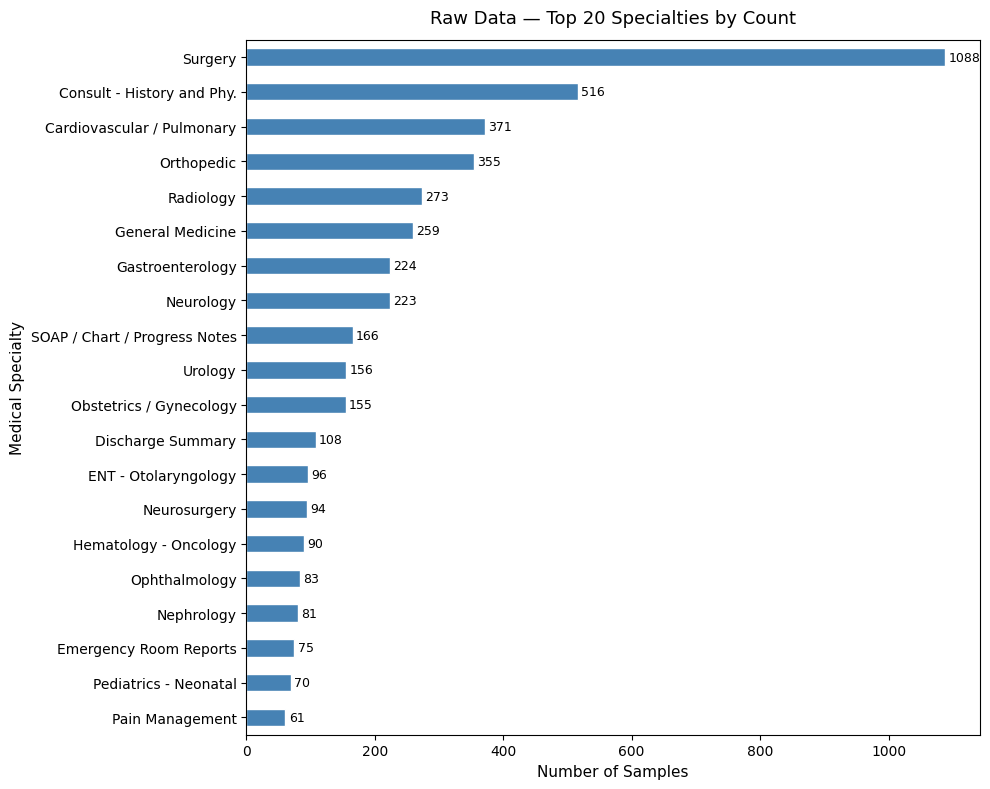

Total samples: 4544 | Specialties: 20


In [ ]:
# Class Distribution Plot
plot_class_distribution(
    df_raw20,
    title='Raw Data — Top 20 Specialties by Count',
    save_path='raw20_class_distribution.png'
)

In [ ]:
# Label Encoding
df_raw20, le_raw20 = encode_labels(df_raw20, 'label_encoder_raw20.pkl')
test_encode_labels(df_raw20, le_raw20, expected_classes=20)

print('\nLabel mapping:')
print(df_raw20[['medical_specialty', 'label']]
      .drop_duplicates().sort_values('label').to_string(index=False))

LabelEncoder saved to label_encoder_raw20.pkl
Classes: ['Cardiovascular / Pulmonary', 'Consult - History and Phy.', 'Discharge Summary', 'ENT - Otolaryngology', 'Emergency Room Reports', 'Gastroenterology', 'General Medicine', 'Hematology - Oncology', 'Nephrology', 'Neurology', 'Neurosurgery', 'Obstetrics / Gynecology', 'Ophthalmology', 'Orthopedic', 'Pain Management', 'Pediatrics - Neonatal', 'Radiology', 'SOAP / Chart / Progress Notes', 'Surgery', 'Urology']

test_encode_labels passed (20 classes)

Label mapping:
            medical_specialty  label
   Cardiovascular / Pulmonary      0
   Consult - History and Phy.      1
            Discharge Summary      2
         ENT - Otolaryngology      3
       Emergency Room Reports      4
             Gastroenterology      5
             General Medicine      6
        Hematology - Oncology      7
                   Nephrology      8
                    Neurology      9
                 Neurosurgery     10
      Obstetrics / Gynecology     1

In [ ]:
# Smart Truncation
df_raw20 = prepare_transcription(df_raw20)
test_prepare_transcription(df_raw20)
print(f'Sample truncated text (first 300 chars):')
print(df_raw20['truncated'].iloc[0][:300])


test_prepare_transcription passed
Sample truncated text (first 300 chars):
2-D M-MODE: , ,1. Left atrial enlargement with left atrial diameter of 4.7 cm.,2. Normal size right and left ventricle.,3. Normal LV systolic function with left ventricular ejection fraction of 51%.,4. Normal LV diastolic function.,5. No pericardial effusion.,6. Normal morphology of aortic valve, mi


### 4.1 Experiment 1 - Raw Data + Train/Test Split

In [ ]:
# Split
train_raw_tts, test_raw_tts = split_train_test(
    df_raw20, CONFIG['test_size'], CONFIG['random_state']
)
test_split(train_raw_tts, test_raw_tts, df_raw20, num_classes=20)

print('\nTrain class distribution:')
print(train_raw_tts['medical_specialty'].value_counts())

Train/Test Split -> Train: 3635 | Test: 909

test_split passed (20 classes in both splits)

Train class distribution:
medical_specialty
Surgery                          870
Consult - History and Phy.       413
Cardiovascular / Pulmonary       297
Orthopedic                       284
Radiology                        218
General Medicine                 207
Gastroenterology                 179
Neurology                        178
SOAP / Chart / Progress Notes    133
Urology                          125
Obstetrics / Gynecology          124
Discharge Summary                 86
ENT - Otolaryngology              77
Neurosurgery                      75
Hematology - Oncology             72
Ophthalmology                     67
Nephrology                        65
Emergency Room Reports            60
Pediatrics - Neonatal             56
Pain Management                   49
Name: count, dtype: int64



  EXPERIMENT: exp1_raw_tts
  Train: 3635 | Test: 909 | Classes: 20

Sub-train: 3271 | Val: 364 | Test: 909
Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/719 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


test_dataset passed
Train batches: 205 | Val batches: 23 | Test batches: 57

test_compute_class_weights passed (20 classes)
Loading BioM-BERT-Large...


...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: sultan/BioM-BERT-PubMed-PMC-Large
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from 

Model loaded | Parameters: 334,627,860
Total steps: 1230 | Warmup: 123

Starting training for 6 epochs...


Epoch 1/6
----------------------------------------


model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

  Batch [50/205] Loss: 3.0438
  Batch [100/205] Loss: 2.7379
  Batch [150/205] Loss: 1.9411
  Batch [200/205] Loss: 2.1387

Epoch 1 Summary:
  Train -> Loss: 2.6065 | Acc: 0.2015
  Val   -> Loss: 1.8051  | Acc: 0.3709 | F1: 0.3694 | Prec: 0.3535 | Rec: 0.5360
    New best model saved (F1: 0.3694)

Epoch 2/6
----------------------------------------
  Batch [50/205] Loss: 1.7610
  Batch [100/205] Loss: 1.5668
  Batch [150/205] Loss: 1.3143
  Batch [200/205] Loss: 1.5461

Epoch 2 Summary:
  Train -> Loss: 1.5715 | Acc: 0.3990
  Val   -> Loss: 1.4969  | Acc: 0.3819 | F1: 0.3945 | Prec: 0.3521 | Rec: 0.5799
    New best model saved (F1: 0.3945)

Epoch 3/6
----------------------------------------
  Batch [50/205] Loss: 0.8962
  Batch [100/205] Loss: 0.8936
  Batch [150/205] Loss: 1.8626
  Batch [200/205] Loss: 1.5568

Epoch 3 Summary:
  Train -> Loss: 1.3009 | Acc: 0.4228
  Val   -> Loss: 1.4311  | Acc: 0.3791 | F1: 0.4080 | Prec: 0.3913 | Rec: 0.5846
    New best model saved (F1: 0.4080)

E

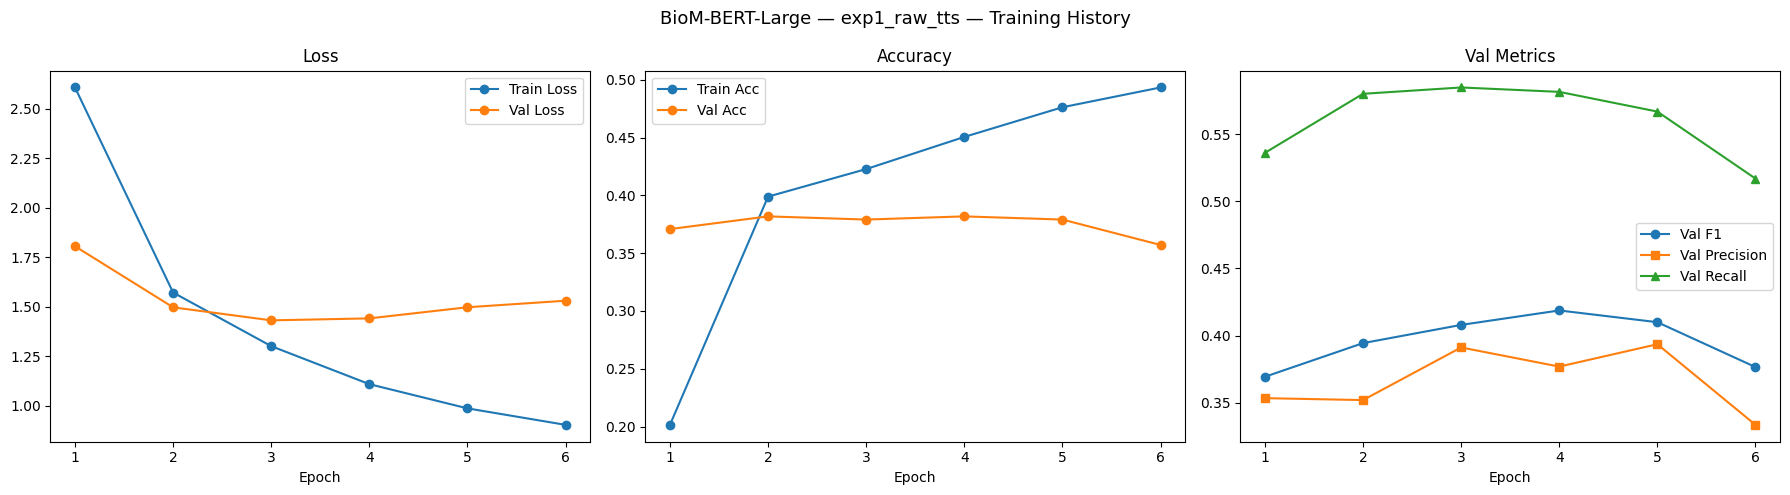


test_plot_confusion_matrix passed (20x20)
Confusion matrix saved: exp1_raw_tts_confusion.png


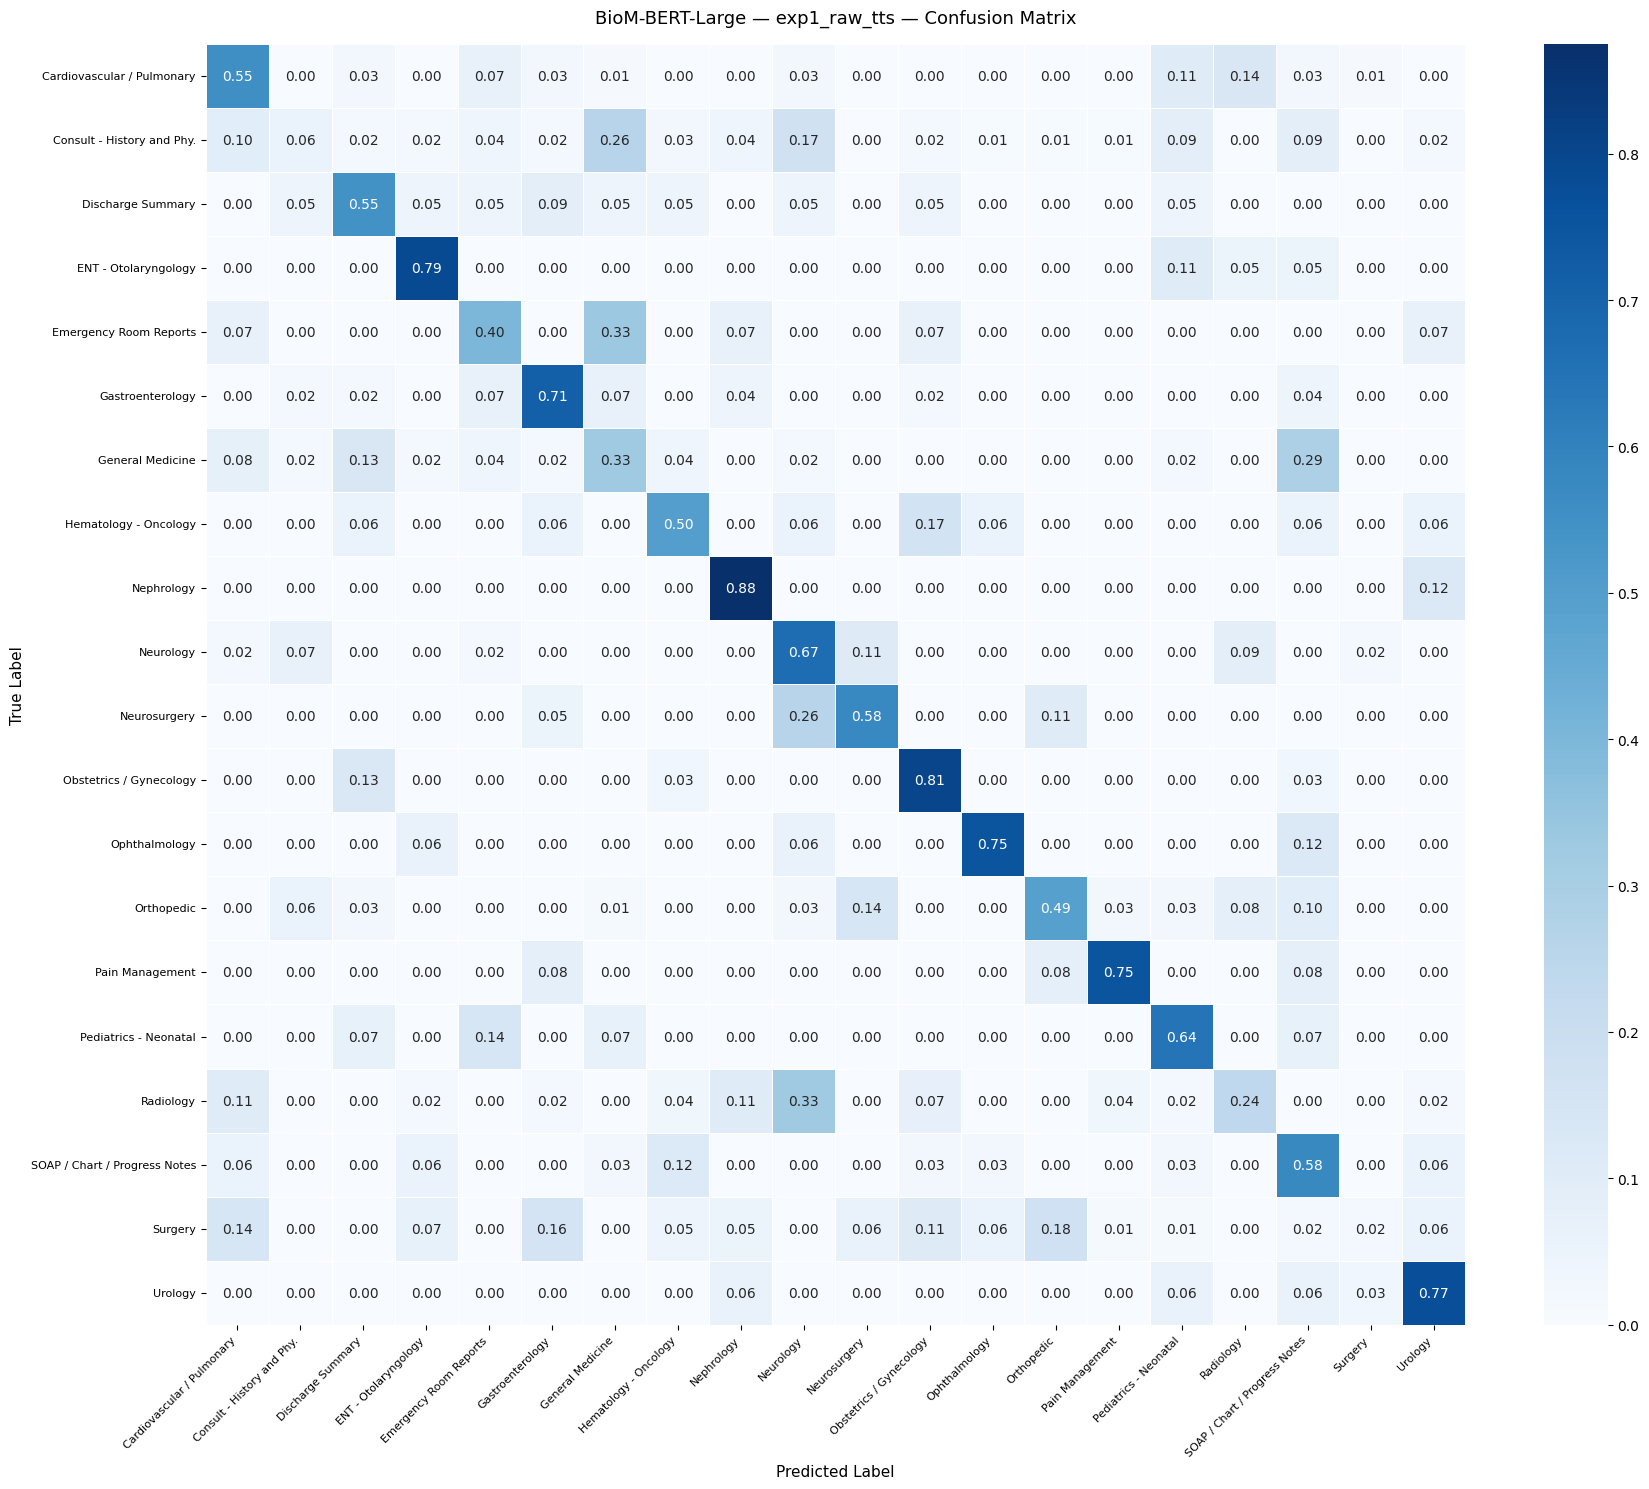


Artifacts saved for exp1_raw_tts:
  exp1_raw_tts_model.pt
  exp1_raw_tts_history.png
  exp1_raw_tts_confusion.png
  exp1_raw_tts_tokenizer/


In [ ]:
# Run Experiment 1
results = {}
model_exp1, history_exp1, preds_exp1, labels_exp1 = run_experiment(
    train_df      = train_raw_tts,
    test_df       = test_raw_tts,
    label_encoder = le_raw20,
    num_classes   = 20,
    exp_name      = 'exp1_raw_tts',
    results_store = results,
    val_size      = 0.1        # 10% of train as val
)

### 4.2 Experiment 2 - Raw Data + GroupShuffleSplit

In [ ]:
# Split
train_raw_gss, test_raw_gss = split_group_shuffle(
    df_raw20, CONFIG['test_size'], CONFIG['random_state']
)

print('\nTrain class distribution:')
print(train_raw_gss['medical_specialty'].value_counts())

GroupShuffleSplit -> Train: 3621 | Test: 923
Transcription overlap: 0 (should be 0)

Train class distribution:
medical_specialty
Surgery                          888
Consult - History and Phy.       409
Cardiovascular / Pulmonary       291
Orthopedic                       285
Radiology                        209
General Medicine                 198
Gastroenterology                 184
Neurology                        169
SOAP / Chart / Progress Notes    130
Obstetrics / Gynecology          125
Urology                          121
Discharge Summary                 85
Neurosurgery                      80
ENT - Otolaryngology              72
Hematology - Oncology             69
Ophthalmology                     68
Nephrology                        65
Emergency Room Reports            61
Pediatrics - Neonatal             58
Pain Management                   54
Name: count, dtype: int64



  EXPERIMENT: exp2_raw_gss
  Train: 3621 | Test: 923 | Classes: 20

Sub-train: 2715 | Val: 906 | Test: 923
Loading tokenizer...

test_dataset passed
Train batches: 170 | Val batches: 57 | Test batches: 58

test_compute_class_weights passed (20 classes)
Loading BioM-BERT-Large...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: sultan/BioM-BERT-PubMed-PMC-Large
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from 

Model loaded | Parameters: 334,627,860
Total steps: 1020 | Warmup: 102

Starting training for 6 epochs...


Epoch 1/6
----------------------------------------
  Batch [50/170] Loss: 3.0047
  Batch [100/170] Loss: 2.7526
  Batch [150/170] Loss: 2.1148

Epoch 1 Summary:
  Train -> Loss: 2.7252 | Acc: 0.2107
  Val   -> Loss: 1.9125  | Acc: 0.3764 | F1: 0.3742 | Prec: 0.3620 | Rec: 0.5208
    New best model saved (F1: 0.3742)

Epoch 2/6
----------------------------------------
  Batch [50/170] Loss: 1.6016
  Batch [100/170] Loss: 1.1198
  Batch [150/170] Loss: 1.9634

Epoch 2 Summary:
  Train -> Loss: 1.6362 | Acc: 0.3886
  Val   -> Loss: 1.4613  | Acc: 0.3753 | F1: 0.4019 | Prec: 0.3525 | Rec: 0.5540
    New best model saved (F1: 0.4019)

Epoch 3/6
----------------------------------------
  Batch [50/170] Loss: 1.1629
  Batch [100/170] Loss: 1.3748
  Batch [150/170] Loss: 0.7598

Epoch 3 Summary:
  Train -> Loss: 1.2516 | Acc: 0.4398
  Val   -> Loss: 1.4311  | Acc: 0.3808 | F1: 0.4072 | P

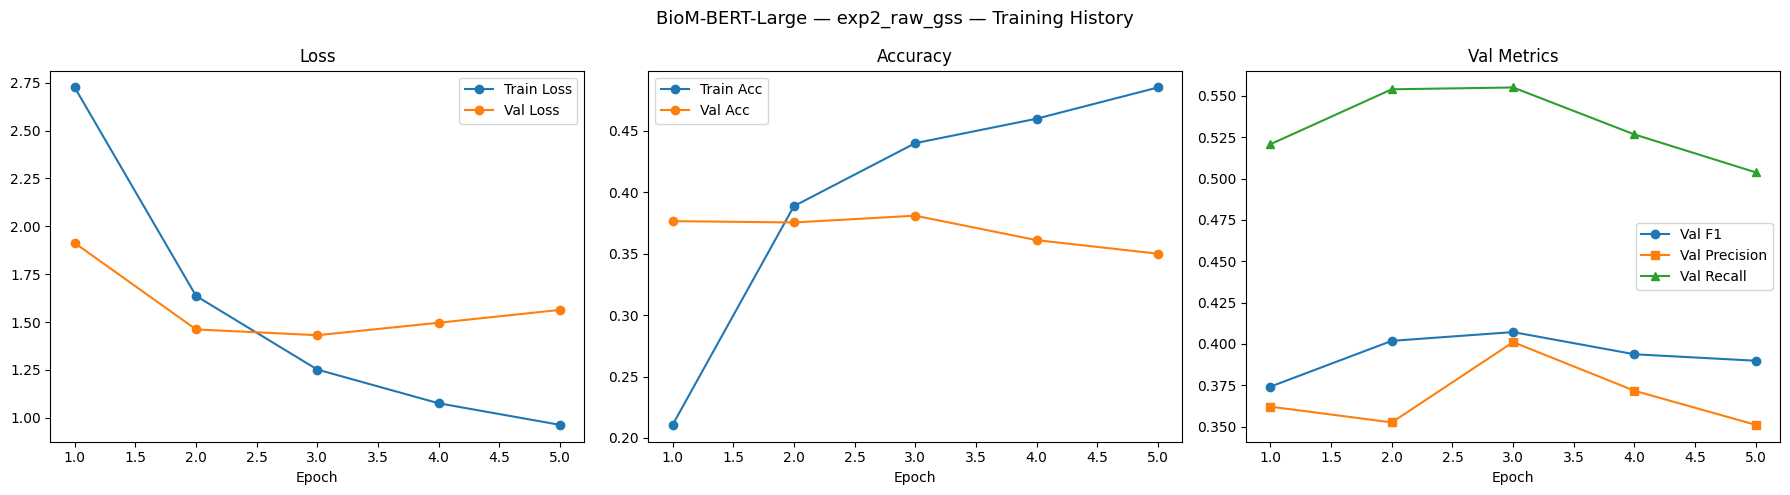


test_plot_confusion_matrix passed (20x20)
Confusion matrix saved: exp2_raw_gss_confusion.png


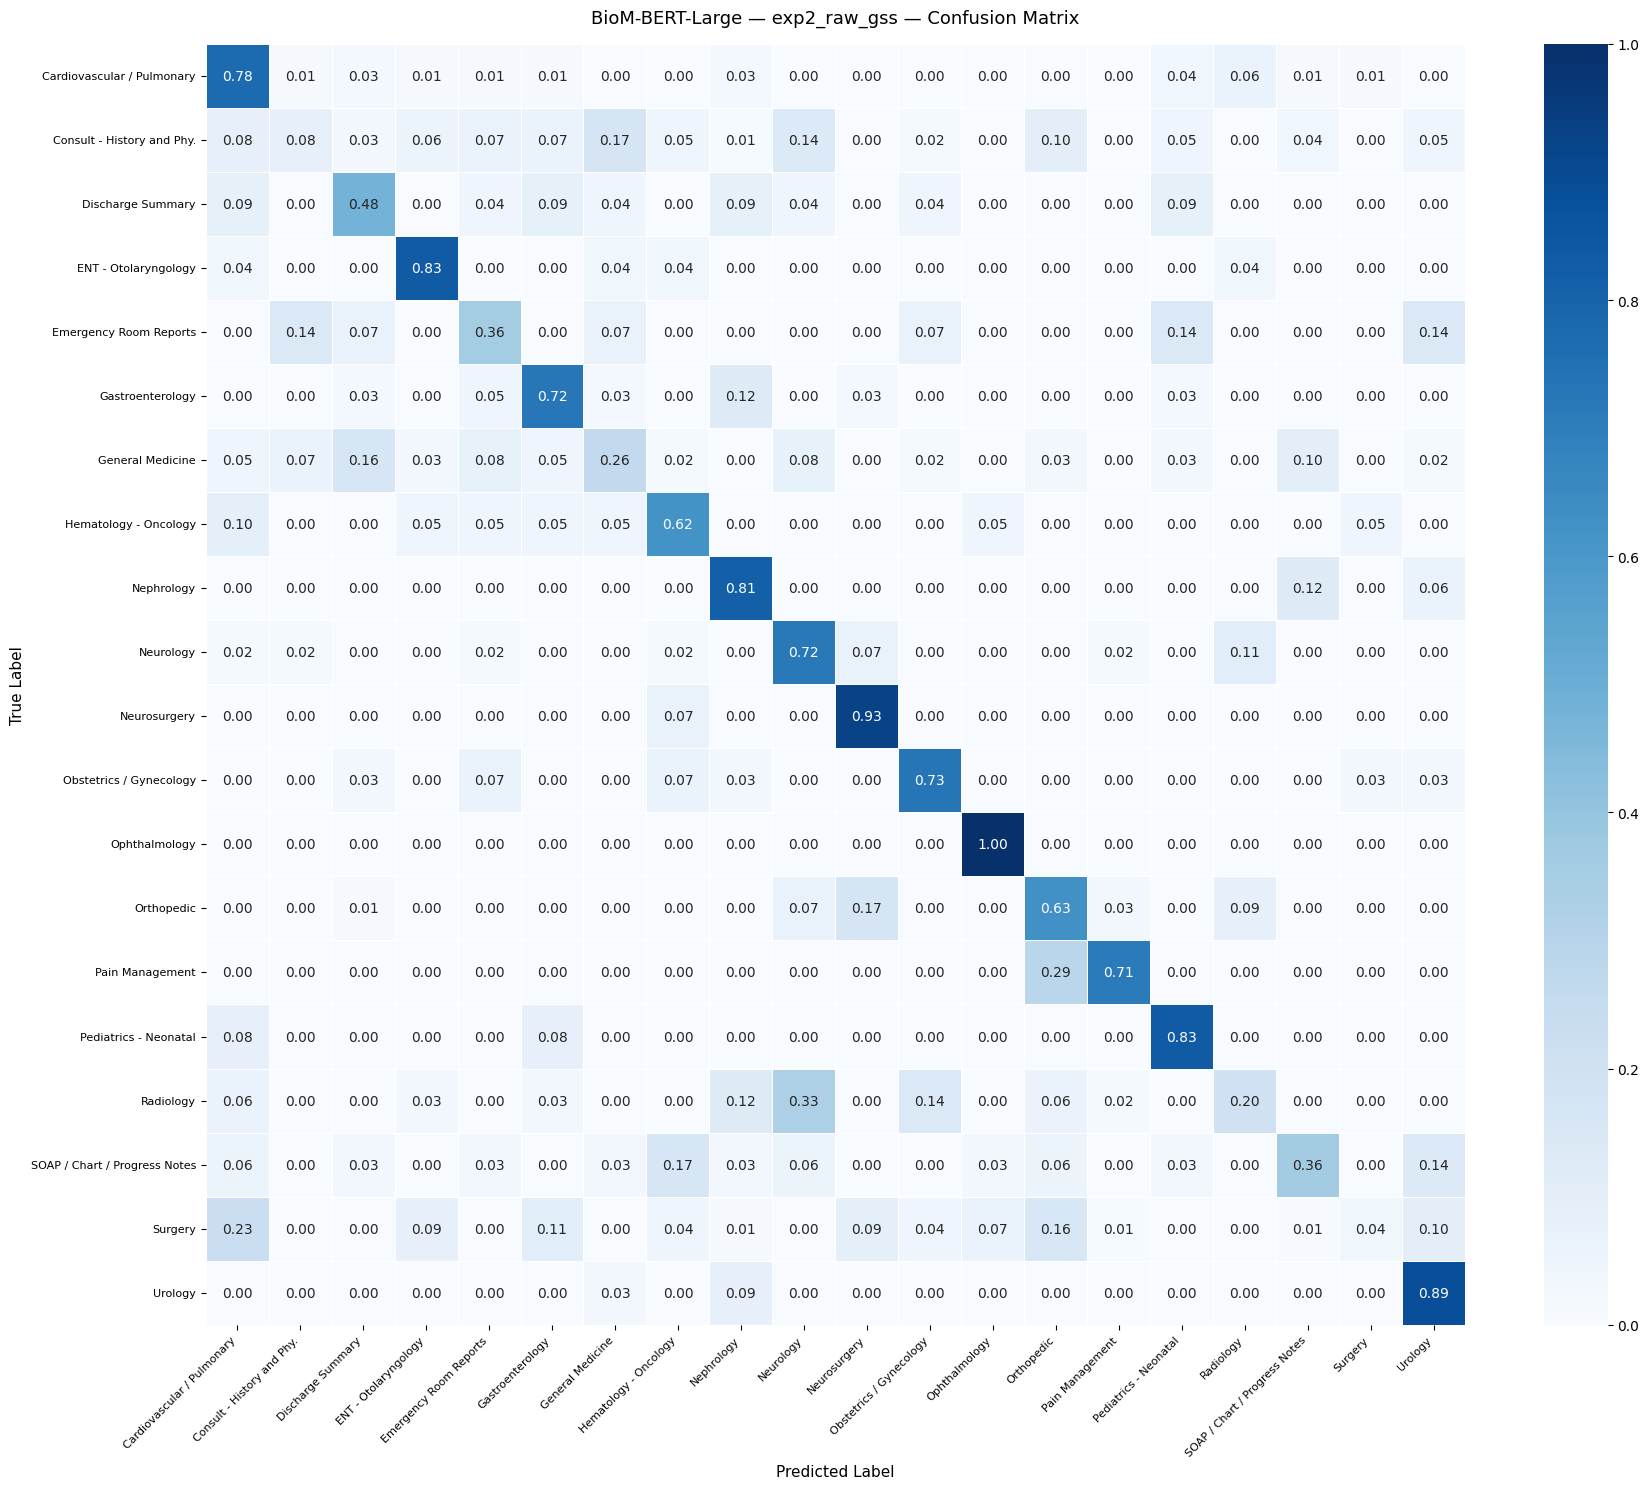


Artifacts saved for exp2_raw_gss:
  exp2_raw_gss_model.pt
  exp2_raw_gss_history.png
  exp2_raw_gss_confusion.png
  exp2_raw_gss_tokenizer/


In [ ]:
# Run Experiment 2
model_exp2, history_exp2, preds_exp2, labels_exp2 = run_experiment(
    train_df      = train_raw_gss,
    test_df       = test_raw_gss,
    label_encoder = le_raw20,
    num_classes   = 20,
    exp_name      = 'exp2_raw_gss',
    results_store = results,
    val_size      = 0.25       # 25% of train as val
)

## 5. Experiment 3 & 4 - Augmented Data (20 Specialties)

### Dataset Description

The augmented dataset (`mtsamples_augmented.csv`) contains 7,530 clinical transcriptions across 20 specialties. Back-translation (English --> French --> English) was used to generate synthetic samples for minority classes:
- Classes ≥ 500 samples -> undersampled to cap
- Classes 100 – 499 -> doubled via back-translation
- Classes 61 – 99 -> tripled via back-translation


In [ ]:
# Load Augmented Data (20 Specialties)
print('Loading augmented dataset (20 specialties)...')
df_aug20 = pd.read_csv('/content/mtsamples_augmented.csv')
df_aug20 = df_aug20.reset_index(drop=True)

print(f'Augmented dataset shape: {df_aug20.shape}')
print(f'Specialties: {df_aug20["medical_specialty"].nunique()}')
print(df_aug20['medical_specialty'].value_counts())

Loading augmented dataset (20 specialties)...
Augmented dataset shape: (7530, 7)
Specialties: 20
medical_specialty
Cardiovascular / Pulmonary       742
Orthopedic                       710
Radiology                        546
General Medicine                 518
Surgery                          500
Consult - History and Phy.       500
Gastroenterology                 448
Neurology                        446
SOAP / Chart / Progress Notes    332
Urology                          312
Obstetrics / Gynecology          310
ENT - Otolaryngology             288
Neurosurgery                     282
Hematology - Oncology            270
Ophthalmology                    249
Nephrology                       243
Emergency Room Reports           225
Discharge Summary                216
Pediatrics - Neonatal            210
Pain Management                  183
Name: count, dtype: int64


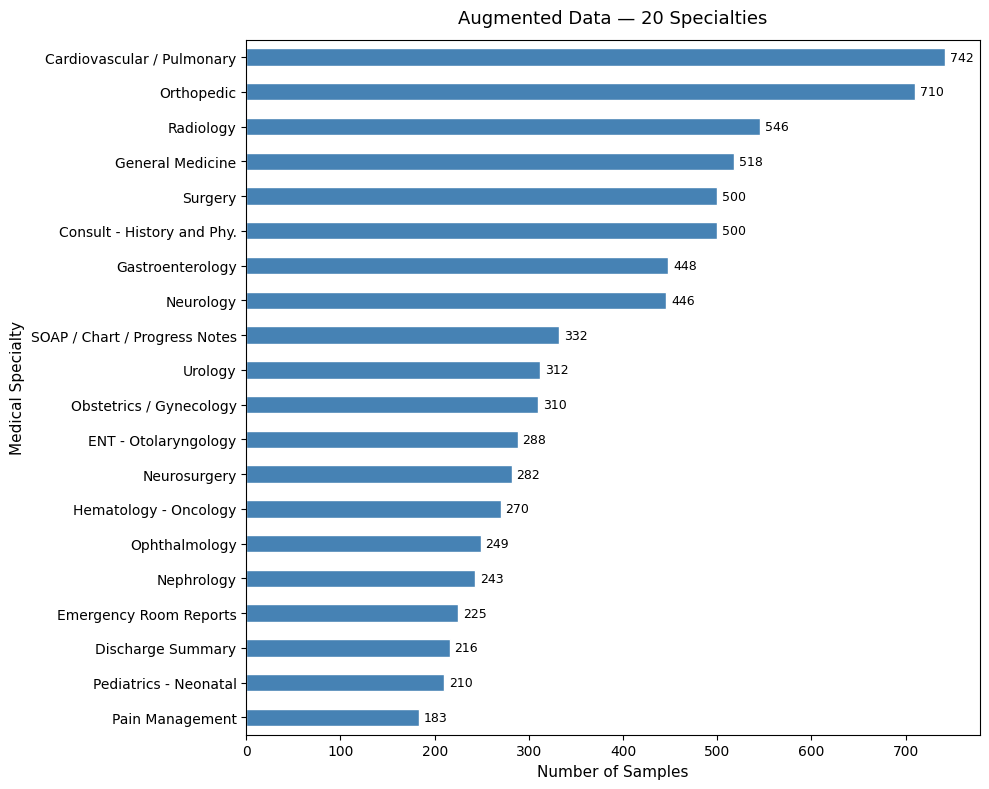

Total samples: 7530 | Specialties: 20


In [ ]:
# Class Distribution Plot
plot_class_distribution(
    df_aug20,
    title='Augmented Data — 20 Specialties',
    save_path='aug20_class_distribution.png'
)

In [ ]:
# Label Encoding
df_aug20, le_aug20 = encode_labels(df_aug20, 'label_encoder_aug20.pkl')
test_encode_labels(df_aug20, le_aug20, expected_classes=20)

print('\nLabel mapping:')
print(df_aug20[['medical_specialty', 'label']]
      .drop_duplicates().sort_values('label').to_string(index=False))

LabelEncoder saved to label_encoder_aug20.pkl
Classes: ['Cardiovascular / Pulmonary', 'Consult - History and Phy.', 'Discharge Summary', 'ENT - Otolaryngology', 'Emergency Room Reports', 'Gastroenterology', 'General Medicine', 'Hematology - Oncology', 'Nephrology', 'Neurology', 'Neurosurgery', 'Obstetrics / Gynecology', 'Ophthalmology', 'Orthopedic', 'Pain Management', 'Pediatrics - Neonatal', 'Radiology', 'SOAP / Chart / Progress Notes', 'Surgery', 'Urology']

test_encode_labels passed (20 classes)

Label mapping:
            medical_specialty  label
   Cardiovascular / Pulmonary      0
   Consult - History and Phy.      1
            Discharge Summary      2
         ENT - Otolaryngology      3
       Emergency Room Reports      4
             Gastroenterology      5
             General Medicine      6
        Hematology - Oncology      7
                   Nephrology      8
                    Neurology      9
                 Neurosurgery     10
      Obstetrics / Gynecology     1

In [ ]:
# Smart Truncation
df_aug20 = prepare_transcription(df_aug20)
test_prepare_transcription(df_aug20)


test_prepare_transcription passed


### 5.1 Experiment 3 - Augmented Data (20) + Train/Test Split

In [ ]:
# Split
train_aug20_tts, test_aug20_tts = split_train_test(
    df_aug20, CONFIG['test_size'], CONFIG['random_state']
)
test_split(train_aug20_tts, test_aug20_tts, df_aug20, num_classes=20)

print('\nTrain class distribution:')
print(train_aug20_tts['medical_specialty'].value_counts())

Train/Test Split -> Train: 6024 | Test: 1506

test_split passed (20 classes in both splits)

Train class distribution:
medical_specialty
Cardiovascular / Pulmonary       594
Orthopedic                       568
Radiology                        437
General Medicine                 414
Consult - History and Phy.       400
Surgery                          400
Gastroenterology                 358
Neurology                        357
SOAP / Chart / Progress Notes    266
Urology                          250
Obstetrics / Gynecology          248
ENT - Otolaryngology             230
Neurosurgery                     226
Hematology - Oncology            216
Ophthalmology                    199
Nephrology                       194
Emergency Room Reports           180
Discharge Summary                173
Pediatrics - Neonatal            168
Pain Management                  146
Name: count, dtype: int64



  EXPERIMENT: exp3_aug20_tts
  Train: 6024 | Test: 1506 | Classes: 20

Sub-train: 5421 | Val: 603 | Test: 1506
Loading tokenizer...

test_dataset passed
Train batches: 339 | Val batches: 38 | Test batches: 95

test_compute_class_weights passed (20 classes)
Loading BioM-BERT-Large...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: sultan/BioM-BERT-PubMed-PMC-Large
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from 

Model loaded | Parameters: 334,627,860
Total steps: 2034 | Warmup: 203

Starting training for 6 epochs...


Epoch 1/6
----------------------------------------
  Batch [50/339] Loss: 2.8673
  Batch [100/339] Loss: 2.9042
  Batch [150/339] Loss: 2.2771
  Batch [200/339] Loss: 1.6535
  Batch [250/339] Loss: 1.4005
  Batch [300/339] Loss: 1.5946

Epoch 1 Summary:
  Train -> Loss: 2.2600 | Acc: 0.3551
  Val   -> Loss: 1.4668  | Acc: 0.5290 | F1: 0.5090 | Prec: 0.5024 | Rec: 0.5850
    New best model saved (F1: 0.5090)

Epoch 2/6
----------------------------------------
  Batch [50/339] Loss: 1.4566
  Batch [100/339] Loss: 0.9374
  Batch [150/339] Loss: 1.0394
  Batch [200/339] Loss: 1.1243
  Batch [250/339] Loss: 1.3075
  Batch [300/339] Loss: 1.2310

Epoch 2 Summary:
  Train -> Loss: 1.2500 | Acc: 0.5584
  Val   -> Loss: 1.2153  | Acc: 0.5556 | F1: 0.5614 | Prec: 0.5486 | Rec: 0.6310
    New best model saved (F1: 0.5614)

Epoch 3/6
----------------------------------------
  Batch [50/339] 

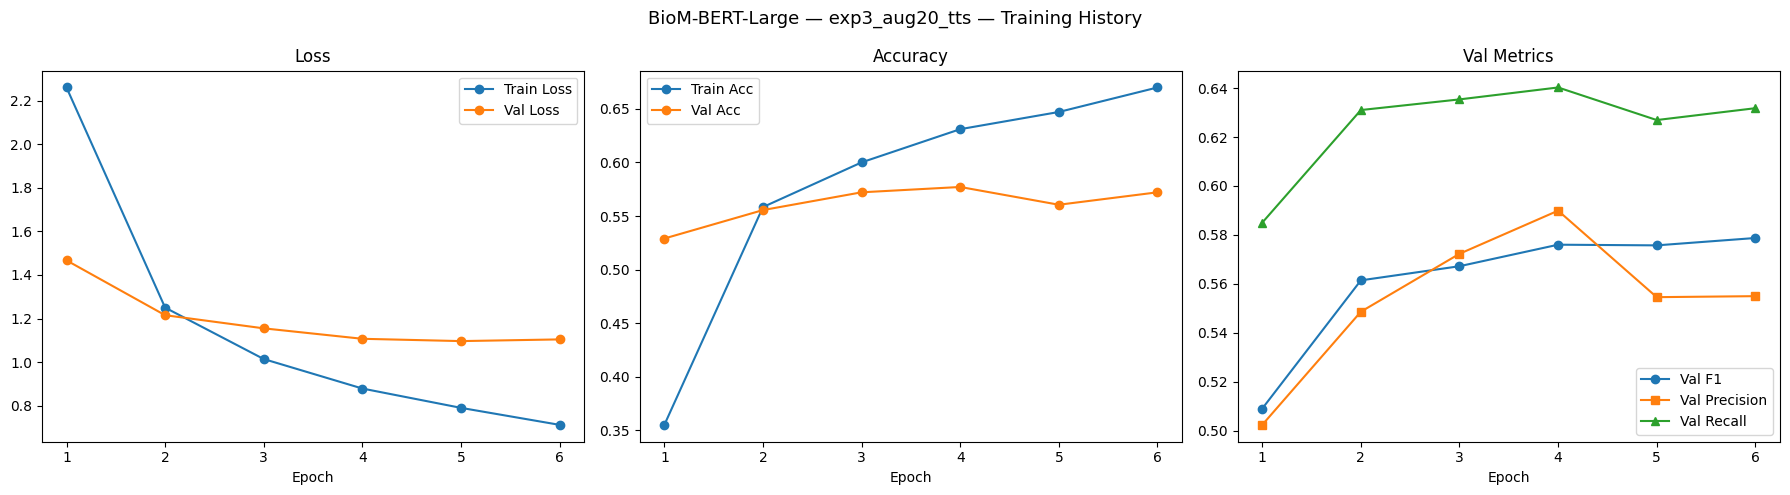


test_plot_confusion_matrix passed (20x20)
Confusion matrix saved: exp3_aug20_tts_confusion.png


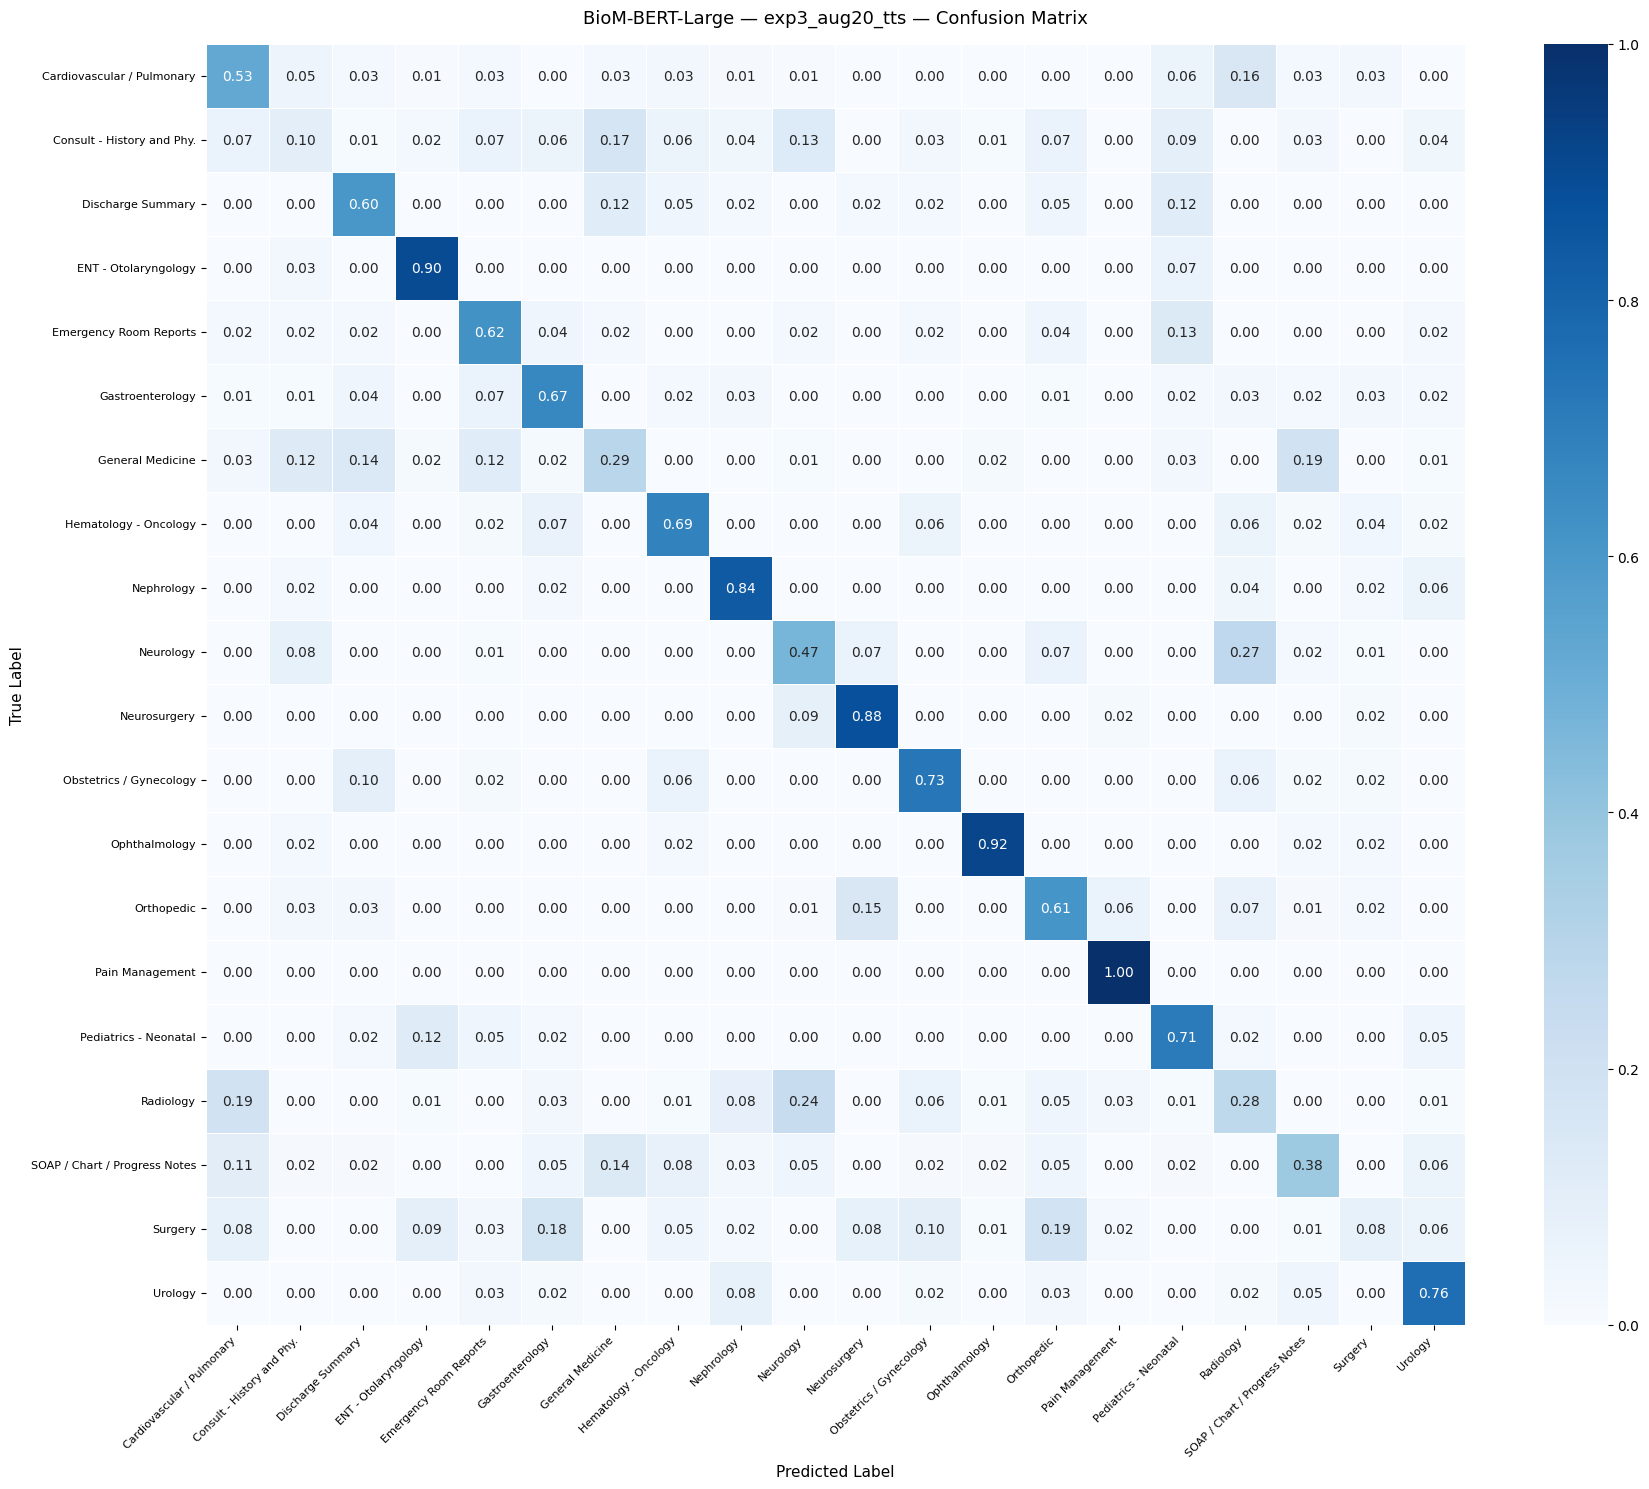


Artifacts saved for exp3_aug20_tts:
  exp3_aug20_tts_model.pt
  exp3_aug20_tts_history.png
  exp3_aug20_tts_confusion.png
  exp3_aug20_tts_tokenizer/


In [ ]:
# Run Experiment 3
model_exp3, history_exp3, preds_exp3, labels_exp3 = run_experiment(
    train_df      = train_aug20_tts,
    test_df       = test_aug20_tts,
    label_encoder = le_aug20,
    num_classes   = 20,
    exp_name      = 'exp3_aug20_tts',
    results_store = results,
    val_size      = 0.1        # 10% of train as val
)

### 5.2 Experiment 4 - Augmented Data (20) + GroupShuffleSplit

In [ ]:
# Split
train_aug20_gss, test_aug20_gss = split_group_shuffle(
    df_aug20, CONFIG['test_size'], CONFIG['random_state']
)

print('\nTrain class distribution:')
print(train_aug20_gss['medical_specialty'].value_counts())

GroupShuffleSplit -> Train: 6011 | Test: 1519
Transcription overlap: 0 (should be 0)

Train class distribution:
medical_specialty
Orthopedic                       572
Cardiovascular / Pulmonary       570
Radiology                        435
General Medicine                 411
Surgery                          400
Consult - History and Phy.       391
Gastroenterology                 373
Neurology                        344
SOAP / Chart / Progress Notes    269
Urology                          259
Obstetrics / Gynecology          250
ENT - Otolaryngology             226
Hematology - Oncology            221
Neurosurgery                     217
Ophthalmology                    212
Nephrology                       203
Emergency Room Reports           175
Discharge Summary                168
Pediatrics - Neonatal            167
Pain Management                  148
Name: count, dtype: int64



  EXPERIMENT: exp4_aug20_gss
  Train: 6011 | Test: 1519 | Classes: 20

Sub-train: 4508 | Val: 1503 | Test: 1519
Loading tokenizer...

test_dataset passed
Train batches: 282 | Val batches: 94 | Test batches: 95

test_compute_class_weights passed (20 classes)
Loading BioM-BERT-Large...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: sultan/BioM-BERT-PubMed-PMC-Large
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from 

Model loaded | Parameters: 334,627,860
Total steps: 1692 | Warmup: 169

Starting training for 6 epochs...


Epoch 1/6
----------------------------------------
  Batch [50/282] Loss: 2.9605
  Batch [100/282] Loss: 2.9009
  Batch [150/282] Loss: 2.1661
  Batch [200/282] Loss: 1.3049
  Batch [250/282] Loss: 1.9678

Epoch 1 Summary:
  Train -> Loss: 2.3871 | Acc: 0.3152
  Val   -> Loss: 1.4830  | Acc: 0.5289 | F1: 0.4794 | Prec: 0.5310 | Rec: 0.5639
    New best model saved (F1: 0.4794)

Epoch 2/6
----------------------------------------
  Batch [50/282] Loss: 1.2767
  Batch [100/282] Loss: 1.4353
  Batch [150/282] Loss: 1.9032
  Batch [200/282] Loss: 1.4149
  Batch [250/282] Loss: 1.3161

Epoch 2 Summary:
  Train -> Loss: 1.3297 | Acc: 0.5581
  Val   -> Loss: 1.2514  | Acc: 0.5396 | F1: 0.5377 | Prec: 0.5311 | Rec: 0.5993
    New best model saved (F1: 0.5377)

Epoch 3/6
----------------------------------------
  Batch [50/282] Loss: 1.5391
  Batch [100/282] Loss: 1.1176
  Batch [150/282] 

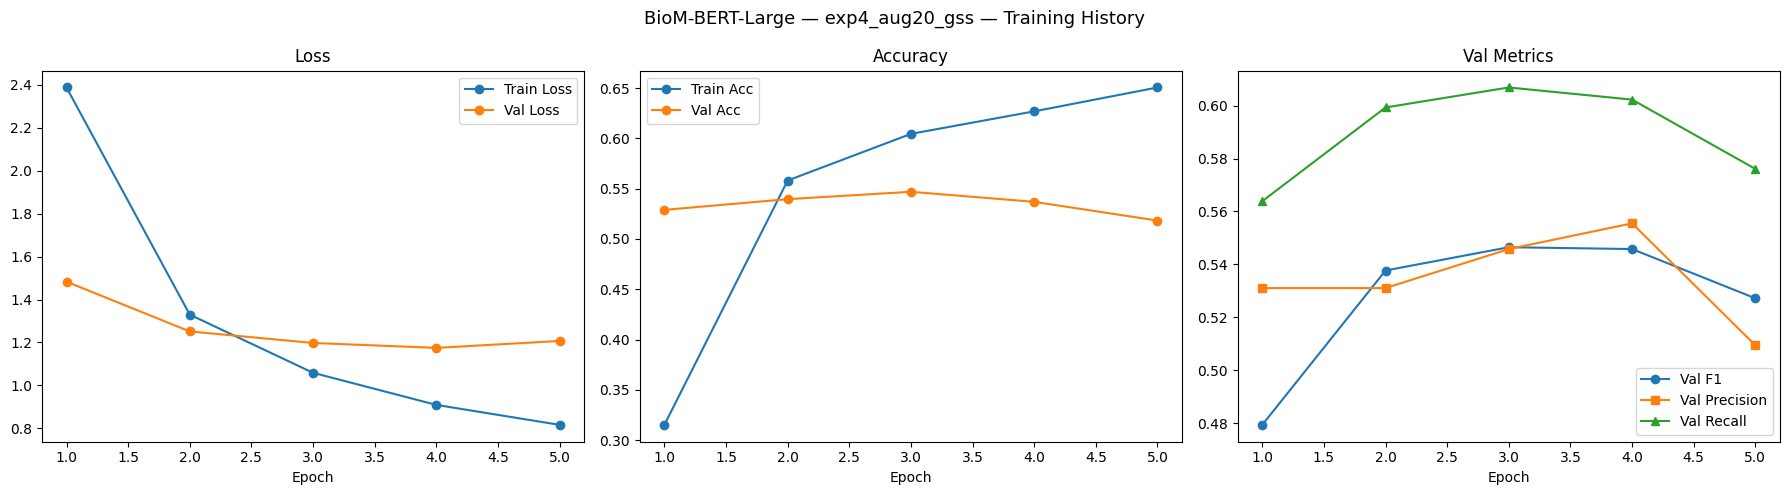


test_plot_confusion_matrix passed (20x20)
Confusion matrix saved: exp4_aug20_gss_confusion.png


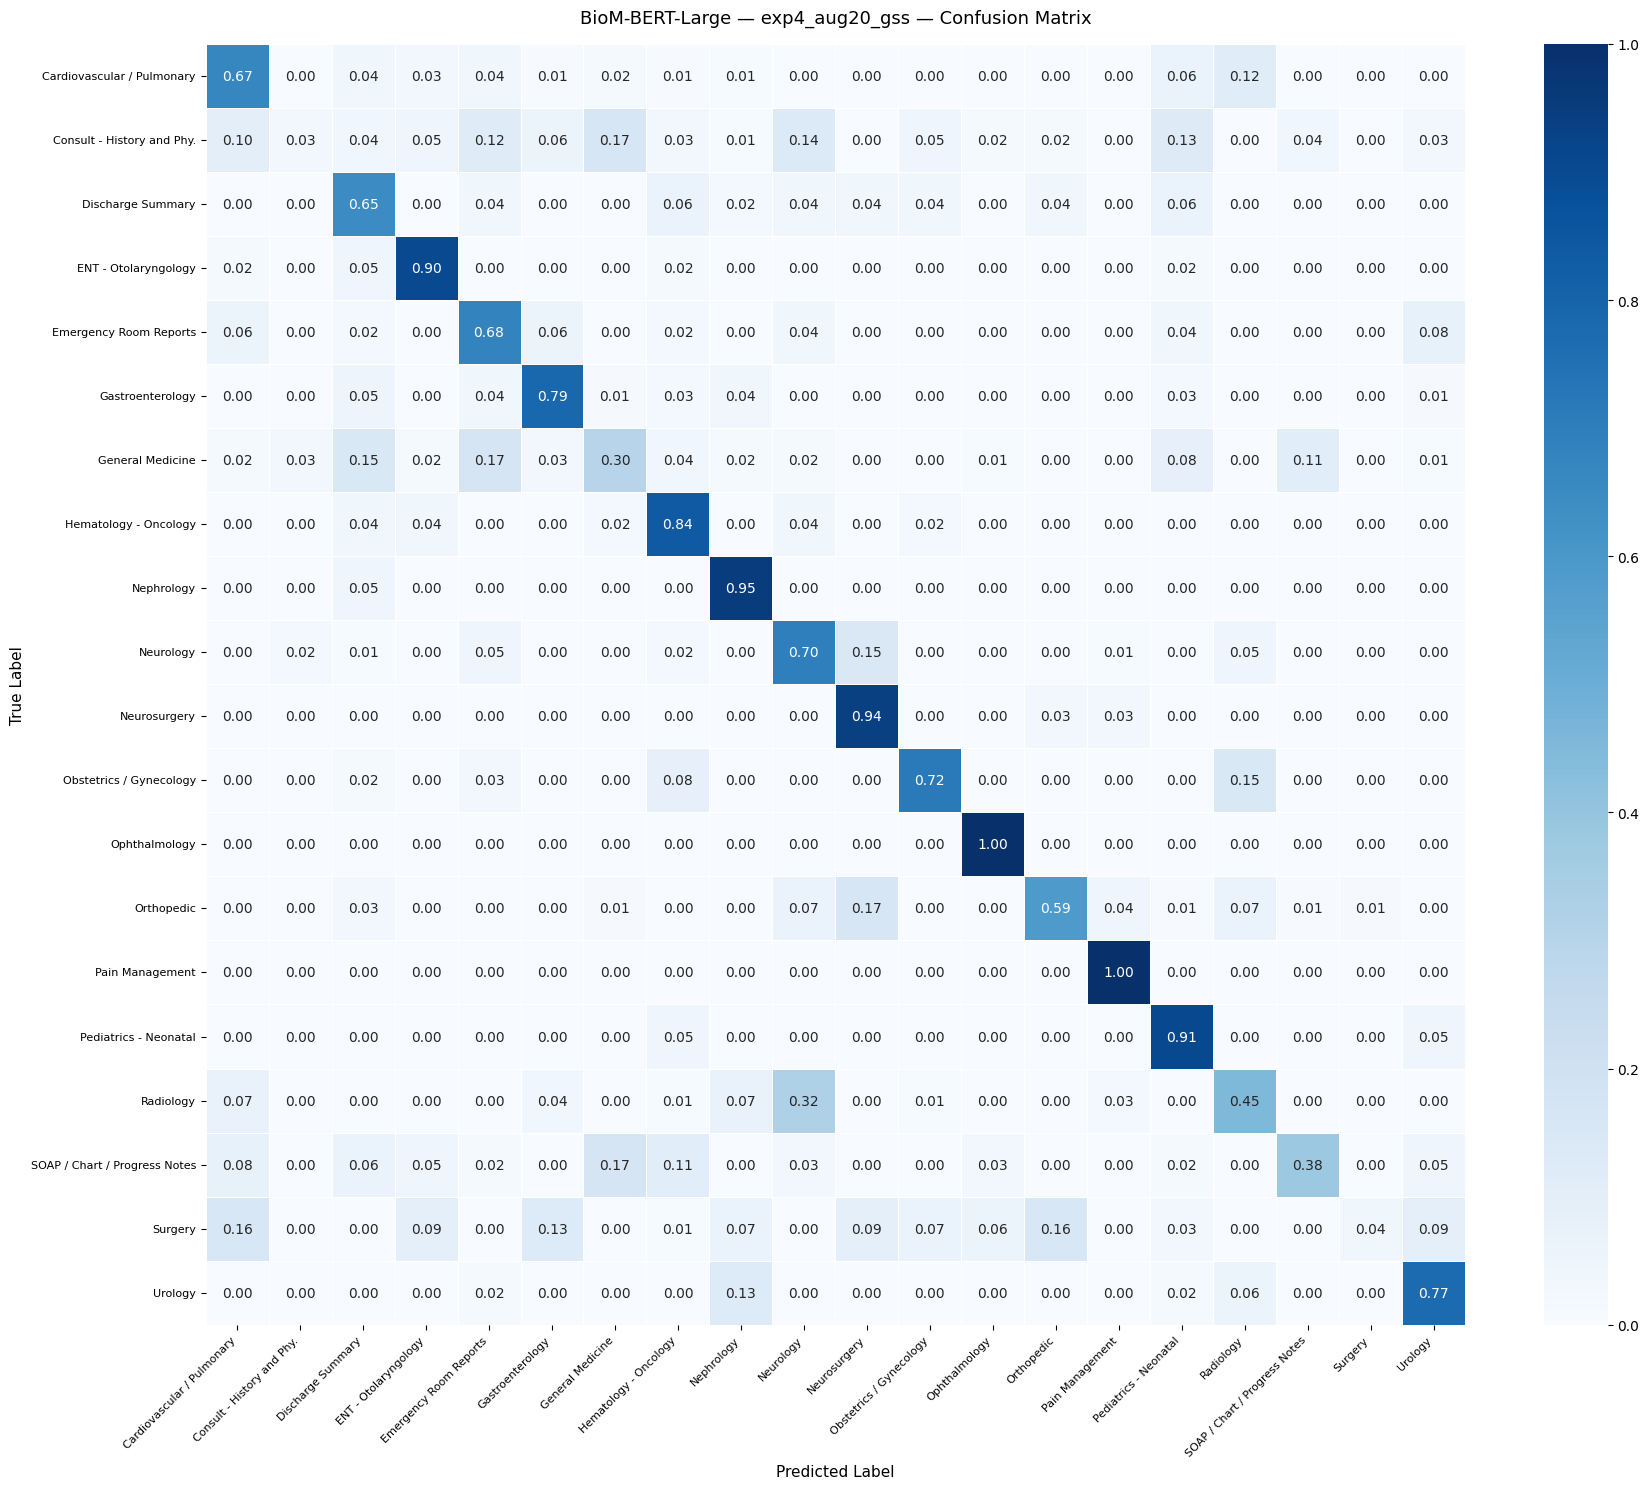


Artifacts saved for exp4_aug20_gss:
  exp4_aug20_gss_model.pt
  exp4_aug20_gss_history.png
  exp4_aug20_gss_confusion.png
  exp4_aug20_gss_tokenizer/


In [ ]:
# Run Experiment 4
model_exp4, history_exp4, preds_exp4, labels_exp4 = run_experiment(
    train_df      = train_aug20_gss,
    test_df       = test_aug20_gss,
    label_encoder = le_aug20,
    num_classes   = 20,
    exp_name      = 'exp4_aug20_gss',
    results_store = results,
    val_size      = 0.25       # 25% of train as val
)

## 6. Experiment 5 & 6 - Refined Augmented Data (15 Specialties)

### Dataset Description

The refined dataset (`augmented_mtsamples.csv`) removes 5 **document-type labels** from the augmented 20-specialty dataset. These labels describe the *format* of a clinical note rather than a *medical domain*, causing systematic misclassification:

| Removed Specialty | Reason |
|-------------------|--------|
| Surgery | Procedural wrapper - contains notes from all surgical subspecialties |
| Consult - History and Phy. | Document type - consultation notes span all domains |
| Radiology | Document type - radiology reports span all imaging domains |
| SOAP / Chart / Progress Notes | Document format - not a medical domain |
| Discharge Summary | Document type - discharge notes span all domains |

The model cannot reliably distinguish these from domain-specific specialties because their vocabulary inherently overlaps with all other classes. This is a **label taxonomy issue**, not a model limitation.

In [ ]:
# Load Refined Augmented Data (15 Specialties)
print('Loading refined augmented dataset (15 specialties)...')
df_aug15 = pd.read_csv('/content/augmented_mtsamples.csv')
df_aug15 = df_aug15.reset_index(drop=True)

print(f'Refined dataset shape: {df_aug15.shape}')
print(f'Specialties: {df_aug15["medical_specialty"].nunique()}')
print(df_aug15['medical_specialty'].value_counts())

Loading refined augmented dataset (15 specialties)...
Refined dataset shape: (5436, 7)
Specialties: 15
medical_specialty
Cardiovascular / Pulmonary    742
Orthopedic                    710
General Medicine              518
Gastroenterology              448
Neurology                     446
Urology                       312
Obstetrics / Gynecology       310
ENT - Otolaryngology          288
Neurosurgery                  282
Hematology - Oncology         270
Ophthalmology                 249
Nephrology                    243
Emergency Room Reports        225
Pediatrics - Neonatal         210
Pain Management               183
Name: count, dtype: int64


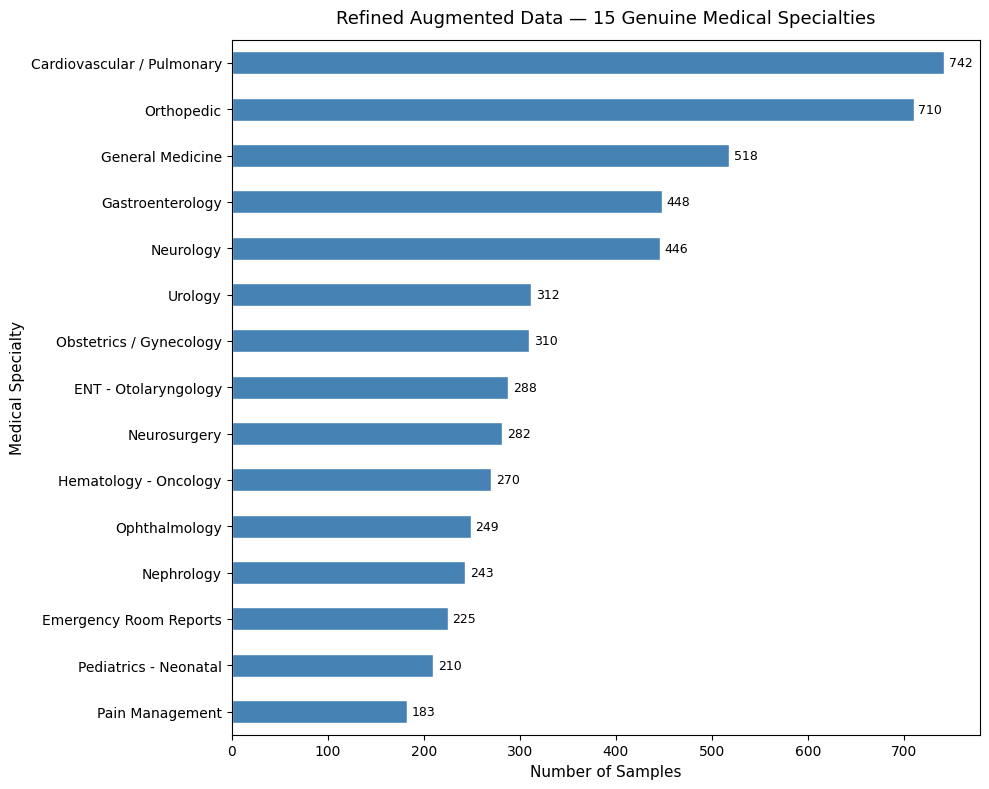

Total samples: 5436 | Specialties: 15


In [ ]:
# Class Distribution Plot
plot_class_distribution(
    df_aug15,
    title='Refined Augmented Data — 15 Genuine Medical Specialties',
    save_path='aug15_class_distribution.png'
)

In [ ]:
# Label Encoding
df_aug15, le_aug15 = encode_labels(df_aug15, 'label_encoder_aug15.pkl')
test_encode_labels(df_aug15, le_aug15, expected_classes=15)

print('\nLabel mapping:')
print(df_aug15[['medical_specialty', 'label']]
      .drop_duplicates().sort_values('label').to_string(index=False))

LabelEncoder saved to label_encoder_aug15.pkl
Classes: ['Cardiovascular / Pulmonary', 'ENT - Otolaryngology', 'Emergency Room Reports', 'Gastroenterology', 'General Medicine', 'Hematology - Oncology', 'Nephrology', 'Neurology', 'Neurosurgery', 'Obstetrics / Gynecology', 'Ophthalmology', 'Orthopedic', 'Pain Management', 'Pediatrics - Neonatal', 'Urology']

test_encode_labels passed (15 classes)

Label mapping:
         medical_specialty  label
Cardiovascular / Pulmonary      0
      ENT - Otolaryngology      1
    Emergency Room Reports      2
          Gastroenterology      3
          General Medicine      4
     Hematology - Oncology      5
                Nephrology      6
                 Neurology      7
              Neurosurgery      8
   Obstetrics / Gynecology      9
             Ophthalmology     10
                Orthopedic     11
           Pain Management     12
     Pediatrics - Neonatal     13
                   Urology     14


In [ ]:
# Smart Truncation
df_aug15 = prepare_transcription(df_aug15)
test_prepare_transcription(df_aug15)


test_prepare_transcription passed


### 6.1 Experiment 5 - Refined Data (15) + Train/Test Split

In [ ]:
# Split
train_aug15_tts, test_aug15_tts = split_train_test(
    df_aug15, CONFIG['test_size'], CONFIG['random_state']
)
test_split(train_aug15_tts, test_aug15_tts, df_aug15, num_classes=15)

print('\nTrain class distribution:')
print(train_aug15_tts['medical_specialty'].value_counts())

Train/Test Split -> Train: 4348 | Test: 1088

test_split passed (15 classes in both splits)

Train class distribution:
medical_specialty
Cardiovascular / Pulmonary    594
Orthopedic                    568
General Medicine              414
Gastroenterology              358
Neurology                     357
Urology                       250
Obstetrics / Gynecology       248
ENT - Otolaryngology          230
Neurosurgery                  226
Hematology - Oncology         216
Ophthalmology                 199
Nephrology                    194
Emergency Room Reports        180
Pediatrics - Neonatal         168
Pain Management               146
Name: count, dtype: int64



  EXPERIMENT: exp5_aug15_tts
  Train: 4348 | Test: 1088 | Classes: 15

Sub-train: 3913 | Val: 435 | Test: 1088
Loading tokenizer...

test_dataset passed
Train batches: 245 | Val batches: 28 | Test batches: 68

test_compute_class_weights passed (15 classes)
Loading BioM-BERT-Large...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: sultan/BioM-BERT-PubMed-PMC-Large
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from 

Model loaded | Parameters: 334,622,735
Total steps: 1470 | Warmup: 147

Starting training for 6 epochs...


Epoch 1/6
----------------------------------------
  Batch [50/245] Loss: 2.6217
  Batch [100/245] Loss: 2.3785
  Batch [150/245] Loss: 1.5606
  Batch [200/245] Loss: 1.0498

Epoch 1 Summary:
  Train -> Loss: 1.8308 | Acc: 0.4771
  Val   -> Loss: 0.8013  | Acc: 0.7379 | F1: 0.7343 | Prec: 0.7407 | Rec: 0.7836
    New best model saved (F1: 0.7343)

Epoch 2/6
----------------------------------------
  Batch [50/245] Loss: 0.9543
  Batch [100/245] Loss: 0.6101
  Batch [150/245] Loss: 0.6452
  Batch [200/245] Loss: 0.9142

Epoch 2 Summary:
  Train -> Loss: 0.7114 | Acc: 0.7741
  Val   -> Loss: 0.6458  | Acc: 0.7563 | F1: 0.7583 | Prec: 0.7565 | Rec: 0.7916
    New best model saved (F1: 0.7583)

Epoch 3/6
----------------------------------------
  Batch [50/245] Loss: 0.4172
  Batch [100/245] Loss: 0.5619
  Batch [150/245] Loss: 0.6764
  Batch [200/245] Loss: 0.2486

Epoch 3 Summary:


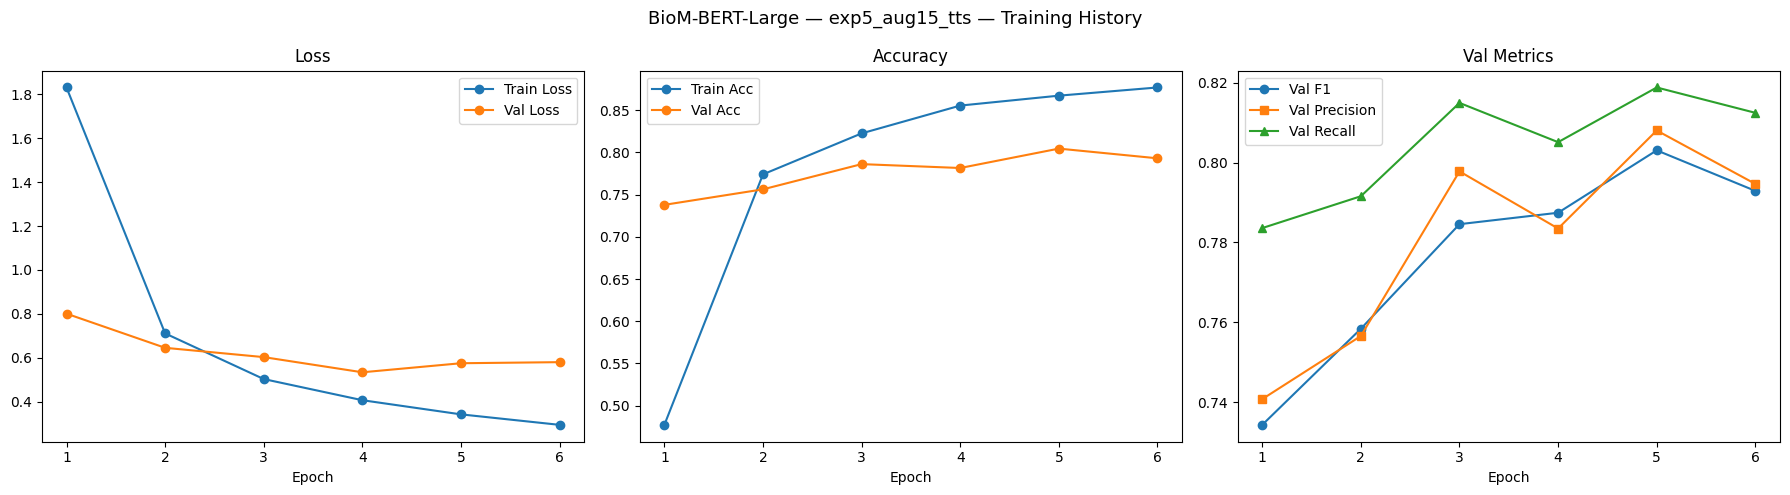


test_plot_confusion_matrix passed (15x15)
Confusion matrix saved: exp5_aug15_tts_confusion.png


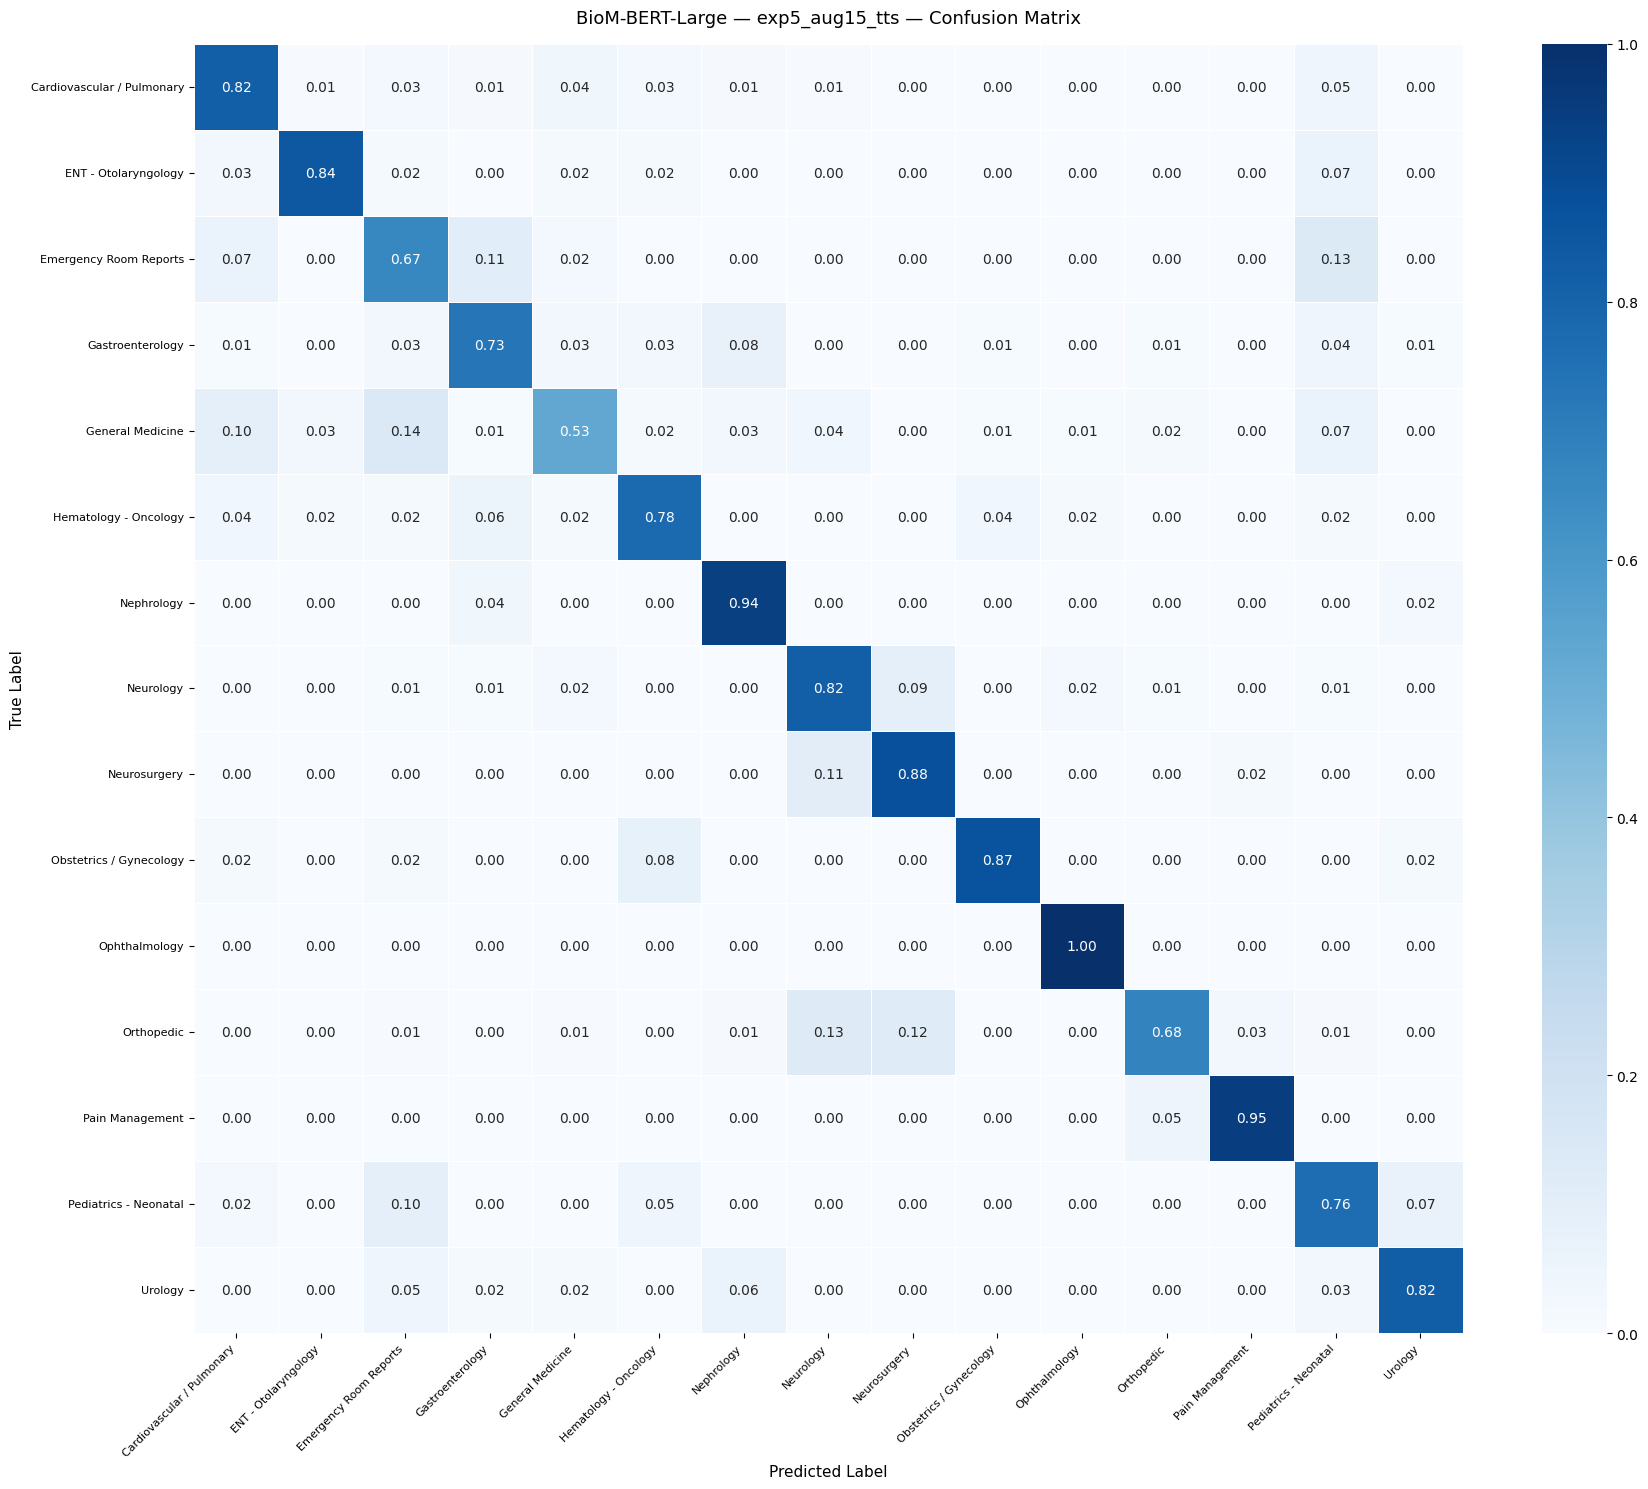


Artifacts saved for exp5_aug15_tts:
  exp5_aug15_tts_model.pt
  exp5_aug15_tts_history.png
  exp5_aug15_tts_confusion.png
  exp5_aug15_tts_tokenizer/


In [ ]:
# Run Experiment 5
model_exp5, history_exp5, preds_exp5, labels_exp5 = run_experiment(
    train_df      = train_aug15_tts,
    test_df       = test_aug15_tts,
    label_encoder = le_aug15,
    num_classes   = 15,
    exp_name      = 'exp5_aug15_tts',
    results_store = results,
    val_size      = 0.1        # 10% of train as val
)

### 6.2 Experiment 6 - Refined Data (15) + GroupShuffleSplit

In [ ]:
# Split
train_aug15_gss, test_aug15_gss = split_group_shuffle(
    df_aug15, CONFIG['test_size'], CONFIG['random_state']
)

print('\nTrain class distribution:')
print(train_aug15_gss['medical_specialty'].value_counts())

GroupShuffleSplit -> Train: 4339 | Test: 1097
Transcription overlap: 0 (should be 0)

Train class distribution:
medical_specialty
Orthopedic                    582
Cardiovascular / Pulmonary    575
General Medicine              407
Gastroenterology              367
Neurology                     350
Urology                       257
Obstetrics / Gynecology       240
Neurosurgery                  236
ENT - Otolaryngology          232
Hematology - Oncology         213
Ophthalmology                 198
Nephrology                    196
Pediatrics - Neonatal         168
Emergency Room Reports        166
Pain Management               152
Name: count, dtype: int64



  EXPERIMENT: exp6_aug15_gss
  Train: 4339 | Test: 1097 | Classes: 15

Sub-train: 3254 | Val: 1085 | Test: 1097
Loading tokenizer...

test_dataset passed
Train batches: 204 | Val batches: 68 | Test batches: 69

test_compute_class_weights passed (15 classes)
Loading BioM-BERT-Large...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: sultan/BioM-BERT-PubMed-PMC-Large
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from 

Model loaded | Parameters: 334,622,735
Total steps: 1224 | Warmup: 122

Starting training for 6 epochs...


Epoch 1/6
----------------------------------------
  Batch [50/204] Loss: 2.6277
  Batch [100/204] Loss: 1.9567
  Batch [150/204] Loss: 0.9835
  Batch [200/204] Loss: 1.1666

Epoch 1 Summary:
  Train -> Loss: 1.9690 | Acc: 0.4465
  Val   -> Loss: 0.8511  | Acc: 0.7585 | F1: 0.7533 | Prec: 0.7488 | Rec: 0.7740
    New best model saved (F1: 0.7533)

Epoch 2/6
----------------------------------------
  Batch [50/204] Loss: 0.8208
  Batch [100/204] Loss: 0.6343
  Batch [150/204] Loss: 0.7040
  Batch [200/204] Loss: 1.1031

Epoch 2 Summary:
  Train -> Loss: 0.7629 | Acc: 0.7541
  Val   -> Loss: 0.6480  | Acc: 0.7797 | F1: 0.7813 | Prec: 0.7786 | Rec: 0.8001
    New best model saved (F1: 0.7813)

Epoch 3/6
----------------------------------------
  Batch [50/204] Loss: 0.5733
  Batch [100/204] Loss: 0.4090
  Batch [150/204] Loss: 0.5726
  Batch [200/204] Loss: 0.2649

Epoch 3 Summary:


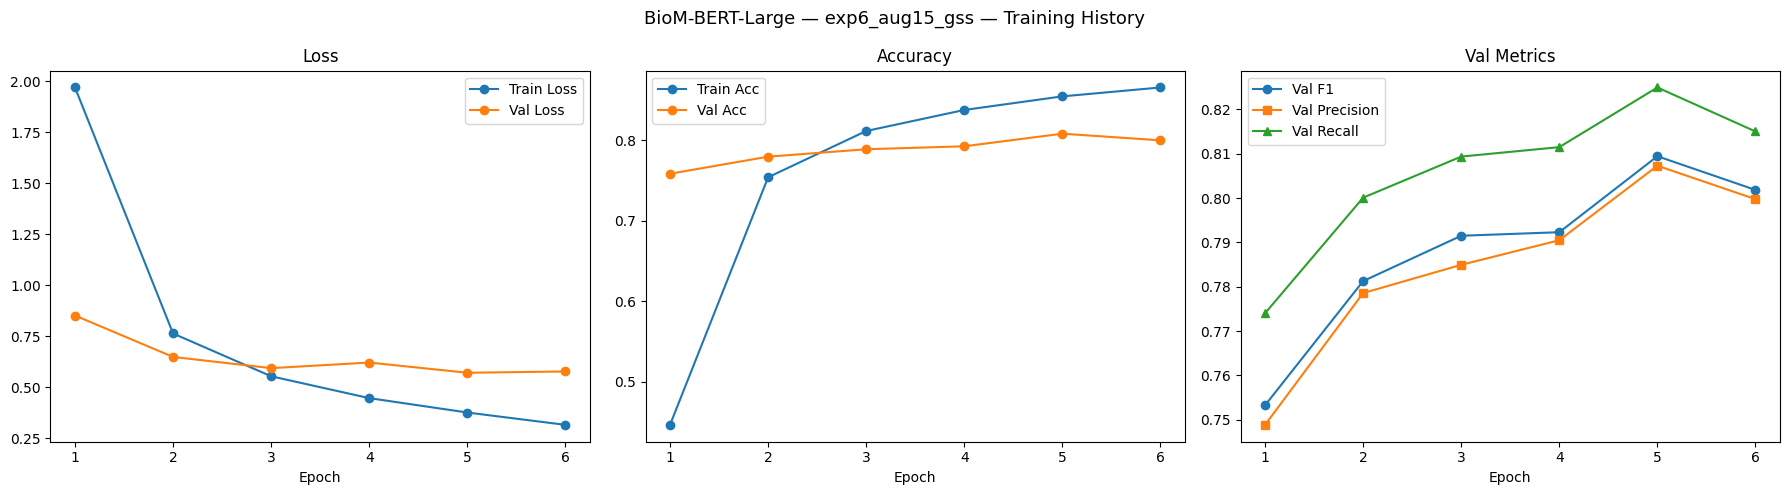


test_plot_confusion_matrix passed (15x15)
Confusion matrix saved: exp6_aug15_gss_confusion.png


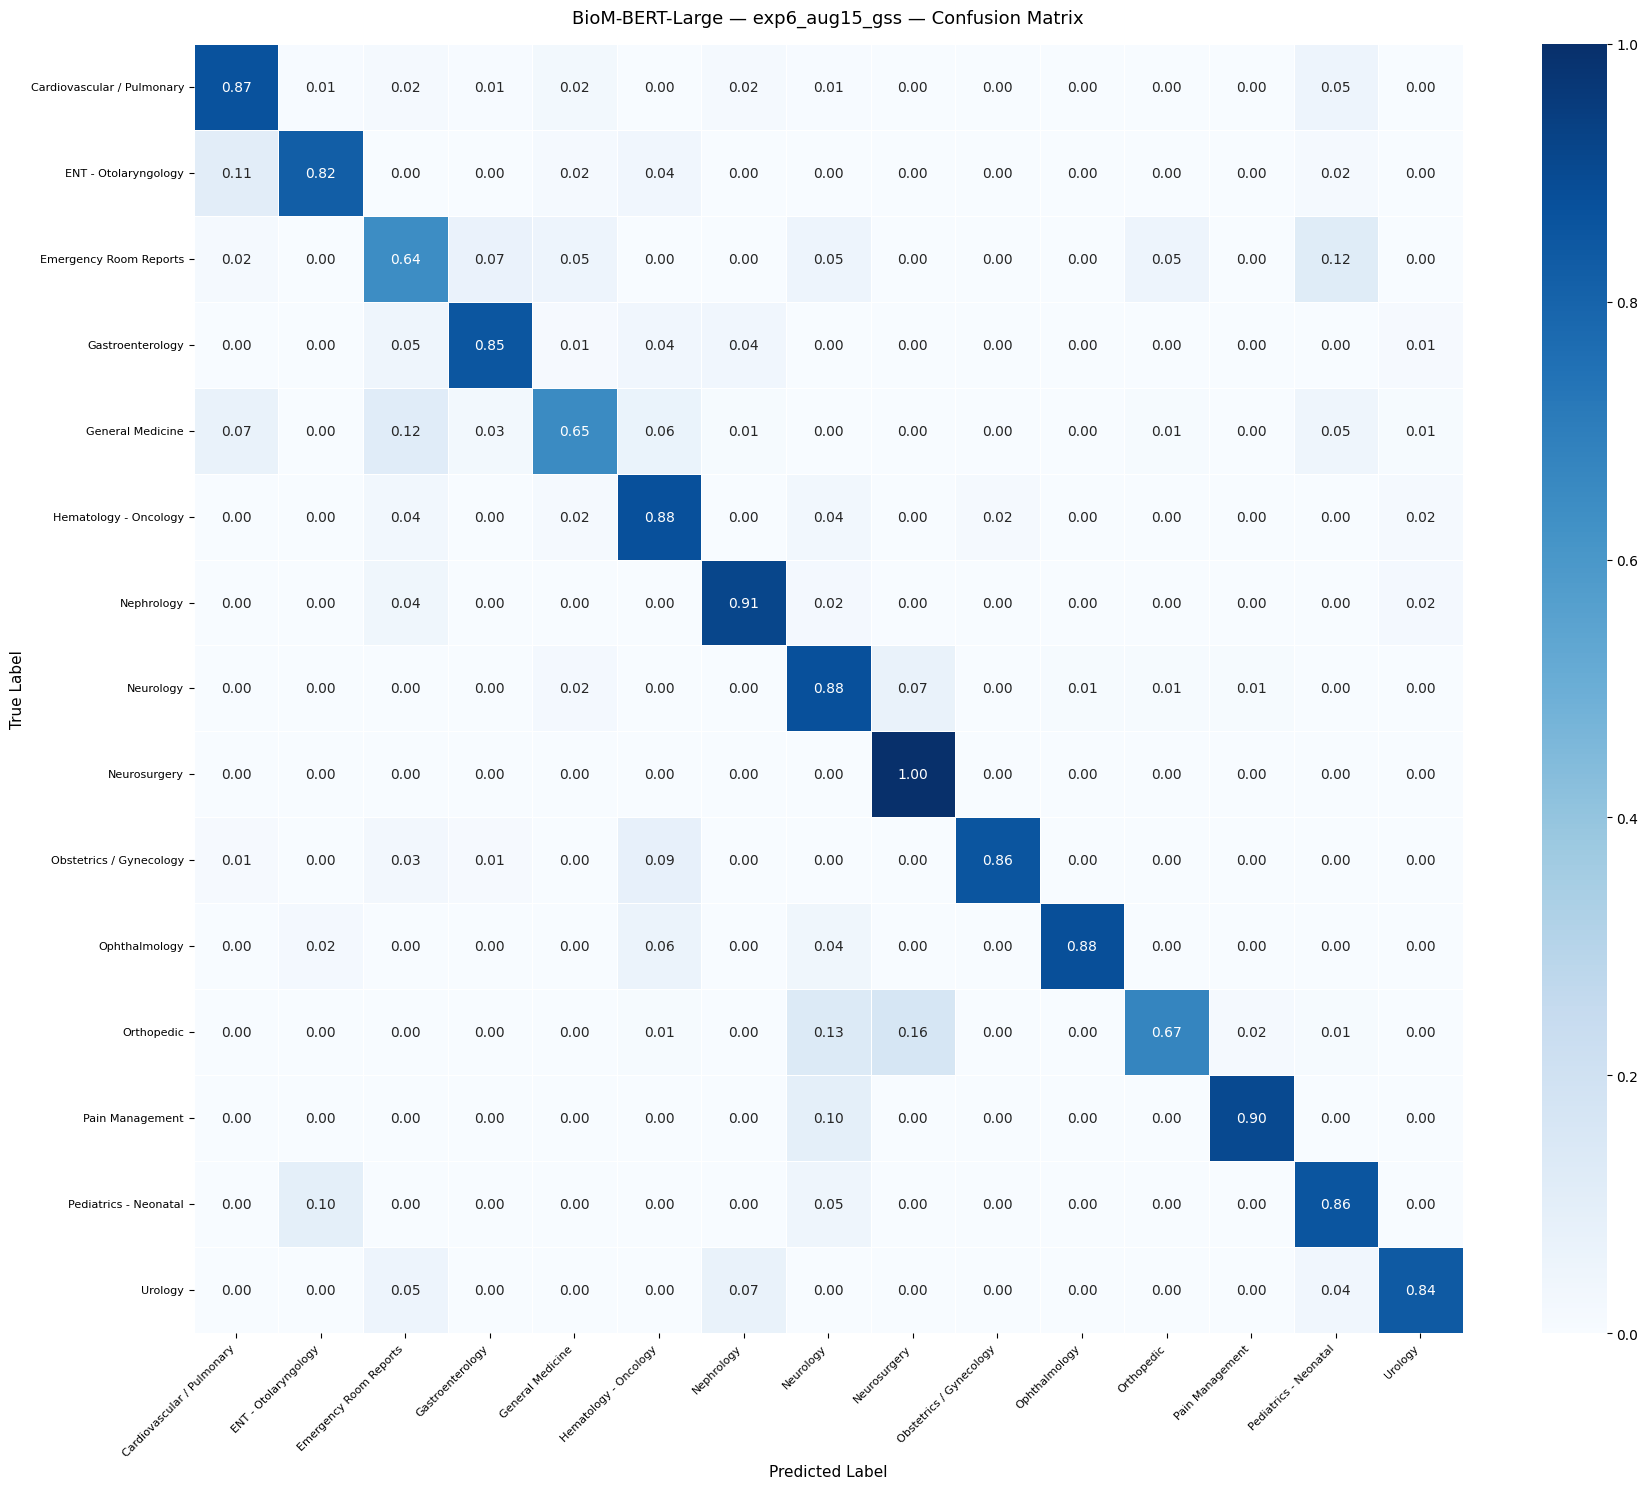


Artifacts saved for exp6_aug15_gss:
  exp6_aug15_gss_model.pt
  exp6_aug15_gss_history.png
  exp6_aug15_gss_confusion.png
  exp6_aug15_gss_tokenizer/


In [ ]:
# Run Experiment 6
model_exp6, history_exp6, preds_exp6, labels_exp6 = run_experiment(
    train_df      = train_aug15_gss,
    test_df       = test_aug15_gss,
    label_encoder = le_aug15,
    num_classes   = 15,
    exp_name      = 'exp6_aug15_gss',
    results_store = results,
    val_size      = 0.25       # 25% of train as val
)

## 7. Results Comparison

### Summary of All 6 Experiments

This section consolidates results across all experiments to enable direct comparison of:
1. The effect of data augmentation on model performance
2. The effect of removing document-type label taxonomy issues
3. The effect of GroupShuffleSplit vs standard Train/Test Split

In [ ]:
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Experiment', 'Accuracy', 'Macro F1', 'Precision', 'Recall',
                       'Num Classes', 'Train Size', 'Val Size', 'Test Size']

results_df['Experiment'] = [
    'Exp 1: Raw (20) + TTS',
    'Exp 2: Raw (20) + GSS',
    'Exp 3: Aug (20) + TTS',
    'Exp 4: Aug (20) + GSS',
    'Exp 5: Aug (15) + TTS',
    'Exp 6: Aug (15) + GSS'
]

print('='*108)
print('FULL RESULTS SUMMARY — BioM-BERT-Large Medical Specialty Classification')
print('='*108)
print(results_df.to_string(index=False))
print('='*108)

FULL RESULTS SUMMARY — BioM-BERT-Large Medical Specialty Classification
           Experiment  Accuracy  Macro F1  Precision  Recall  Num Classes  Train Size  Val Size  Test Size
Exp 1: Raw (20) + TTS    0.3773    0.4130     0.3811  0.5526         20.0      3271.0     364.0      909.0
Exp 2: Raw (20) + GSS    0.4236    0.4447     0.4262  0.5998         20.0      2715.0     906.0      923.0
Exp 3: Aug (20) + TTS    0.5365    0.5493     0.5256  0.6020         20.0      5421.0     603.0     1506.0
Exp 4: Aug (20) + GSS    0.5892    0.5837     0.5872  0.6644         20.0      4508.0    1503.0     1519.0
Exp 5: Aug (15) + TTS    0.7812    0.7834     0.7790  0.8058         15.0      3913.0     435.0     1088.0
Exp 6: Aug (15) + GSS    0.8149    0.8162     0.8172  0.8340         15.0      3254.0    1085.0     1097.0


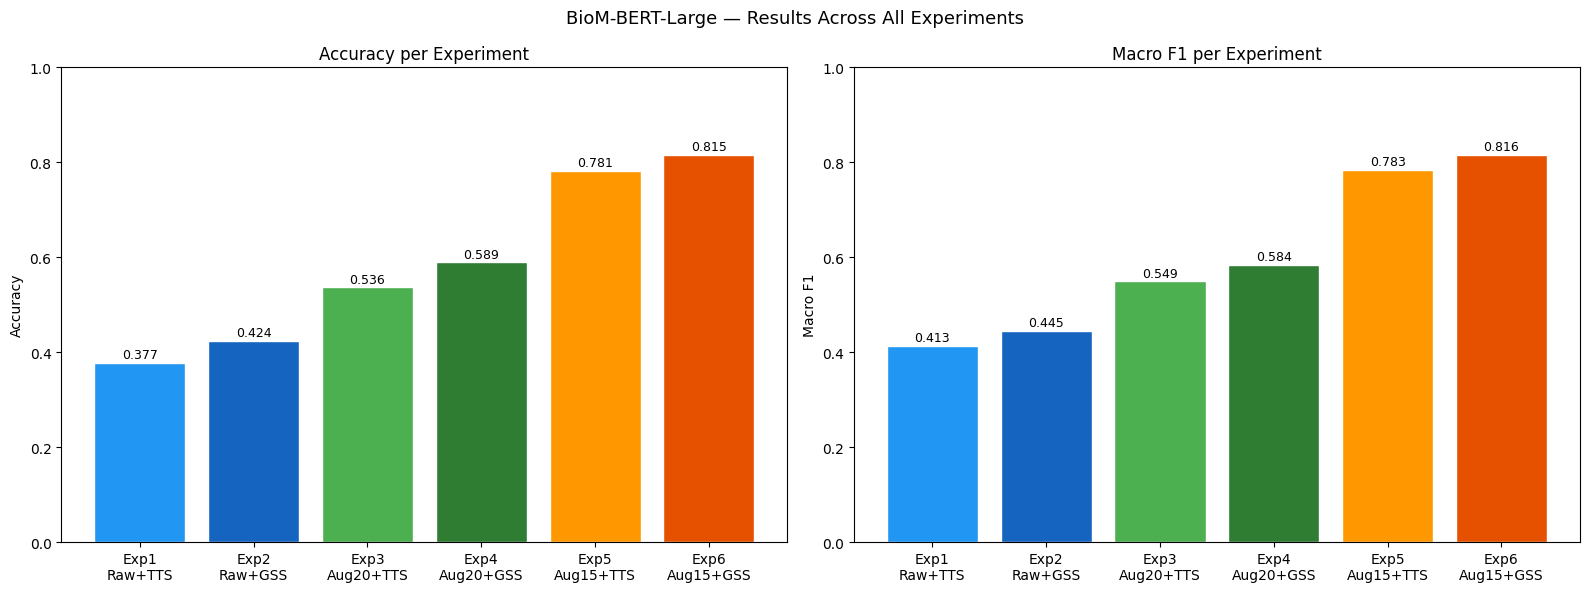

Results comparison plot saved as results_comparison.png


In [ ]:
# Accuracy Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BioM-BERT-Large — Results Across All Experiments', fontsize=13)

colors = ['#2196F3', '#1565C0', '#4CAF50', '#2E7D32', '#FF9800', '#E65100']
exp_labels = [
    'Exp1\nRaw+TTS', 'Exp2\nRaw+GSS',
    'Exp3\nAug20+TTS', 'Exp4\nAug20+GSS',
    'Exp5\nAug15+TTS', 'Exp6\nAug15+GSS'
]

# Accuracy
axes[0].bar(exp_labels, results_df['Accuracy'], color=colors, edgecolor='white')
axes[0].set_title('Accuracy per Experiment')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.0)
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# Macro F1
axes[1].bar(exp_labels, results_df['Macro F1'], color=colors, edgecolor='white')
axes[1].set_title('Macro F1 per Experiment')
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(results_df['Macro F1']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Results comparison plot saved as results_comparison.png')

In [ ]:
# Save All Results to CSV
results_df.to_csv('all_experiments_results.csv', index=False)
print('All results saved to all_experiments_results.csv')

# Print Best Experiment
best_exp = results_df.loc[results_df['Macro F1'].idxmax()]
print(f'\n    Best Experiment: {best_exp["Experiment"]}')
print(f'   Accuracy : {best_exp["Accuracy"]:.4f}')
print(f'   Macro F1 : {best_exp["Macro F1"]:.4f}')
print(f'   Classes  : {int(best_exp["Num Classes"])}')

All results saved to all_experiments_results.csv

    Best Experiment: Exp 6: Aug (15) + GSS
   Accuracy : 0.8149
   Macro F1 : 0.8162
   Classes  : 15


In [ ]:
import os
import shutil

# Create folders
os.makedirs('confusion_matrices',    exist_ok=True)
os.makedirs('training_histories',    exist_ok=True)
os.makedirs('class_distributions',  exist_ok=True)

# Move all figures
for exp in ['exp1_raw_tts', 'exp2_raw_gss', 'exp3_aug20_tts',
            'exp4_aug20_gss', 'exp5_aug15_tts', 'exp6_aug15_gss']:

    for fname, folder in [
        (f'{exp}_confusion.png',  'confusion_matrices'),
        (f'{exp}_history.png',    'training_histories'),
    ]:
        if os.path.exists(fname):
            shutil.move(fname, f'{folder}/{fname}')
            print(f'Moved {fname}')
        else:
            print(f'Not found: {fname}')

# Move class distribution plots
for fname in ['raw20_class_distribution.png',
              'aug20_class_distribution.png',
              'aug15_class_distribution.png']:
    if os.path.exists(fname):
        shutil.move(fname, f'class_distributions/{fname}')
        print(f'Moved {fname}')
    else:
        print(f'Not found: {fname}')

print('\nDone!')
print(f'Confusion matrices : {os.listdir("confusion_matrices")}')
print(f'Training histories : {os.listdir("training_histories")}')
print(f'Class distributions: {os.listdir("class_distributions")}')

Moved exp1_raw_tts_confusion.png
Moved exp1_raw_tts_history.png
Moved exp2_raw_gss_confusion.png
Moved exp2_raw_gss_history.png
Moved exp3_aug20_tts_confusion.png
Moved exp3_aug20_tts_history.png
Moved exp4_aug20_gss_confusion.png
Moved exp4_aug20_gss_history.png
Moved exp5_aug15_tts_confusion.png
Moved exp5_aug15_tts_history.png
Moved exp6_aug15_gss_confusion.png
Moved exp6_aug15_gss_history.png
Moved raw20_class_distribution.png
Moved aug20_class_distribution.png
Moved aug15_class_distribution.png

Done!
Confusion matrices : ['exp1_raw_tts_confusion.png', 'exp6_aug15_gss_confusion.png', 'exp4_aug20_gss_confusion.png', 'exp2_raw_gss_confusion.png', 'exp3_aug20_tts_confusion.png', 'exp5_aug15_tts_confusion.png']
Training histories : ['exp5_aug15_tts_history.png', 'exp3_aug20_tts_history.png', 'exp6_aug15_gss_history.png', 'exp1_raw_tts_history.png', 'exp4_aug20_gss_history.png', 'exp2_raw_gss_history.png']
Class distributions: ['raw20_class_distribution.png', 'aug20_class_distribution.

In [ ]:
import gc
import pickle
import torch

os.makedirs('models_pkl', exist_ok=True)

# Experiment metadata
experiments = [
    {'exp_name': 'exp1_raw_tts',    'label_encoder': le_raw20, 'num_classes': 20},
    {'exp_name': 'exp2_raw_gss',    'label_encoder': le_raw20, 'num_classes': 20},
    {'exp_name': 'exp3_aug20_tts',  'label_encoder': le_aug20, 'num_classes': 20},
    {'exp_name': 'exp4_aug20_gss',  'label_encoder': le_aug20, 'num_classes': 20},
    {'exp_name': 'exp5_aug15_tts',  'label_encoder': le_aug15, 'num_classes': 15},
    {'exp_name': 'exp6_aug15_gss',  'label_encoder': le_aug15, 'num_classes': 15},
]

for exp in experiments:
    exp_name = exp['exp_name']
    pt_path  = f'{exp_name}_model.pt'
    pkl_path = f'models_pkl/{exp_name}.pkl'

    if not os.path.exists(pt_path):
        print(f'Not found: {pt_path} — skipping')
        continue

    print(f'Packaging {exp_name}...')

    # Load model weights to CPU
    state_dict = torch.load(pt_path, map_location='cpu')

    # Bundle everything needed for inference
    package = {
        'model_state_dict' : state_dict,
        'label_encoder'    : exp['label_encoder'],
        'model_name'       : CONFIG['model_name'],
        'num_classes'      : exp['num_classes'],
        'max_length'       : CONFIG['max_length'],
        'word_limit_front' : CONFIG['word_limit_front'],
        'word_limit_back'  : CONFIG['word_limit_back'],
        'x_test' : exp['x_test'], # Only needed for local testing/evaluation, not strictly inference
        'y_test' : exp['y_test']  # Only needed for local testing/evaluation, not strictly inference
    }

    with open(pkl_path, 'wb') as f:
        pickle.dump(package, f)

    print(f'Saved {pkl_path}')

    # Free memory after each save
    del state_dict, package
    gc.collect()

print(f'\nAll models saved to models_pkl/:')
print(os.listdir('models_pkl'))

Packaging exp1_raw_tts...
Saved models_pkl/exp1_raw_tts.pkl
Packaging exp2_raw_gss...
Saved models_pkl/exp2_raw_gss.pkl
Packaging exp3_aug20_tts...
Saved models_pkl/exp3_aug20_tts.pkl
Packaging exp4_aug20_gss...
Saved models_pkl/exp4_aug20_gss.pkl
Packaging exp5_aug15_tts...
Saved models_pkl/exp5_aug15_tts.pkl
Packaging exp6_aug15_gss...
Saved models_pkl/exp6_aug15_gss.pkl

All models saved to models_pkl/:
['exp5_aug15_tts.pkl', 'exp2_raw_gss.pkl', 'exp6_aug15_gss.pkl', 'exp3_aug20_tts.pkl', 'exp4_aug20_gss.pkl', 'exp1_raw_tts.pkl']


In [ ]:
import zipfile
import os

# Create zip with all files
zip_name = 'BioM_BERT.zip'

# All folders and files to include
folders = [
    'confusion_matrices',
    'training_histories',
    'class_distributions',
    'models_pkl',
    'shared_tokenizer',
]

files = [
    'results_comparison.png',
    'label_encoder_raw20.pkl',
    'label_encoder_aug20.pkl',
    'label_encoder_aug15.pkl',
    'all_experiments_results.csv',
    'augmented_mtsamples.csv',
    'mtsamples_augmented.csv',
    'mtsamples.csv',
]

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:

    # Add folders
    for folder in folders:
        if os.path.exists(folder):
            for root, dirs, filenames in os.walk(folder):
                for filename in filenames:
                    filepath = os.path.join(root, filename)
                    zf.write(filepath)
                    print(f'Added {filepath}')
        else:
            print(f'Folder not found: {folder}')

    # Add individual files
    for file in files:
        if os.path.exists(file):
            zf.write(file)
            print(f'Added {file}')
        else:
            print(f'File not found: {file}')

print(f'\nZip created: {zip_name}')
print(f'   Size: {os.path.getsize(zip_name)/1024**2:.1f} MB')

# Download
from google.colab import files
files.download(zip_name)

Added confusion_matrices/exp1_raw_tts_confusion.png
Added confusion_matrices/exp6_aug15_gss_confusion.png
Added confusion_matrices/exp4_aug20_gss_confusion.png
Added confusion_matrices/exp2_raw_gss_confusion.png
Added confusion_matrices/exp3_aug20_tts_confusion.png
Added confusion_matrices/exp5_aug15_tts_confusion.png
Added training_histories/exp5_aug15_tts_history.png
Added training_histories/exp3_aug20_tts_history.png
Added training_histories/exp6_aug15_gss_history.png
Added training_histories/exp1_raw_tts_history.png
Added training_histories/exp4_aug20_gss_history.png
Added training_histories/exp2_raw_gss_history.png
Added class_distributions/raw20_class_distribution.png
Added class_distributions/aug20_class_distribution.png
Added class_distributions/aug15_class_distribution.png
Added models_pkl/exp5_aug15_tts.pkl
Added models_pkl/exp2_raw_gss.pkl
Added models_pkl/exp6_aug15_gss.pkl
Added models_pkl/exp3_aug20_tts.pkl
Added models_pkl/exp4_aug20_gss.pkl
Added models_pkl/exp1_raw_tts

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>